<a href="https://colab.research.google.com/github/Baelfyre/MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/blob/main/MO_IT117_Data_Visualization_Plan_MO_IT115_A3101_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MO-IT117 Data Visualization Techniques
## Visualization Planning and Exploratory Analysis

**Group 3**

### Purpose

This notebook explores the cleaned Philippine Statistics Authority (PSA) 2024 Internet Use and ICT datasets prepared during Milestone 1.

The purpose of this analysis is to determine which variables, dataset combinations, and visualization techniques can best communicate the state of digital connectivity across Philippine regions.

The notebook uses Python and Seaborn for exploratory analysis before the selected visualizations are implemented in Tableau.

The analysis follows this general process:

**Analytical Question → Purpose → Dataset and Variables → Exploratory Visualization → Evidence → Interpretation → Tableau Recommendation**

The goal is not to create as many charts as possible. Each visualization should answer a clear question, support the project's analytical purpose, and provide useful information to the intended audience.

### Project Analytical Purpose

To present the state of digital connectivity across Philippine regions by examining internet usage, device and network connectivity conditions, and demographic patterns among individuals aged 10 years and over.

The analysis aims to identify areas where connectivity gaps may exist and use the findings to support discussions about digital infrastructure, accessibility, and inclusion.

### Intended Audience

The intended audience includes ICT professionals, government and community decision-makers, students, and general audiences interested in digital connectivity and internet use in the Philippines.

### Data Source

Philippine Statistics Authority (PSA), 2024

Repository:

https://github.com/Baelfyre/MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3

In [242]:
# @title
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
# pandas:
#   Used for loading, filtering, combining, and inspecting data.
#
# numpy:
#   Used for numerical operations when needed.
#
# matplotlib:
#   Provides the base plotting system used by Seaborn.
#
# seaborn:
#   Used for exploratory visualizations that will help us decide
#   which charts and data relationships should later be built
#   in Tableau.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve how tables are displayed inside Google Colab.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Use a clean Seaborn theme for exploratory charts.
# These charts are for analysis, not necessarily the final
# visual design that will be implemented in Tableau.
sns.set_theme(style="whitegrid", context="notebook")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset Sources

The five cleaned datasets are stored in the project's GitHub repository.

Using GitHub as the source allows this notebook to load the same files consistently without requiring manual uploads each time the Colab session is restarted.

The datasets remain separate because they represent different analytical categories:

| Dataset | Main Analytical Category |
|---|---|
| Internet Use by Gender | Gender composition of internet users |
| Internet Use by Age Group | Age composition of internet users |
| Internet Use by Frequency | Frequency of internet use |
| Internet Use by Type | Activities performed on the internet |
| Network, Device, and Signal | Device access and network conditions |

All datasets share **Region** as their common geographic field.

They should not automatically be merged into one large dataset because their category structures and analytical grains are different. Cross-dataset combinations will only be created when a specific analytical question justifies comparing regional indicators.

In [243]:
# @title
# ============================================================
# 2. DEFINE THE CANONICAL GITHUB DATA SOURCES
# ============================================================
# These URLs point directly to the cleaned CSV files stored
# on the main branch of the Group 3 GitHub repository.
#
# Keeping the URLs in one dictionary makes the notebook easier
# to maintain and makes the exact source of every dataframe clear.

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "Baelfyre/"
    "MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/"
    "main/"
)

DATA_URLS = {
    "gender": BASE_URL + "PSA_Internet_Use_Gender_Region_2024_Cleaned.csv",
    "age": BASE_URL + "PSA_Internet_Use_Age_Group_Region_2024_Cleaned.csv",
    "frequency": BASE_URL + "PSA_Internet_Use_Frequency_Region_2024_Cleaned.csv",
    "activity": BASE_URL + "PSA_Internet_Use_Type_Region_2024_Cleaned.csv",
    "network": BASE_URL + "PSA_Network_Devise_and_Signal_Region_2024_Cleaned.csv",
}

print("Dataset source URLs prepared.")

Dataset source URLs prepared.


In [244]:
# @title
# ============================================================
# 3. LOAD THE CLEANED DATASETS
# ============================================================
# Each dataset is loaded into its own dataframe.
#
# We intentionally keep them separate at this stage because each
# dataset has a different categorical grain.

df_gender = pd.read_csv(DATA_URLS["gender"])
df_age = pd.read_csv(DATA_URLS["age"])
df_frequency = pd.read_csv(DATA_URLS["frequency"])
df_activity = pd.read_csv(DATA_URLS["activity"])
df_network = pd.read_csv(DATA_URLS["network"])

# Store the dataframes in a dictionary so the same validation
# checks can easily be applied to all five datasets.

datasets = {
    "Gender": df_gender,
    "Age Group": df_age,
    "Frequency": df_frequency,
    "Internet Activity": df_activity,
    "Network / Device / Signal": df_network,
}

print("All five cleaned PSA datasets loaded successfully.")

All five cleaned PSA datasets loaded successfully.


In [245]:
# @title
# ============================================================
# 4. VERIFY THAT THE DATASETS LOADED CORRECTLY
# ============================================================
# Milestone 1 documented the expected record counts after
# cleaning. We compare the GitHub files against those values
# rather than assuming the files loaded correctly.

expected_rows = {
    "Gender": 54,
    "Age Group": 180,
    "Frequency": 90,
    "Internet Activity": 396,
    "Network / Device / Signal": 90,
}

load_summary = []

for name, df in datasets.items():
    actual_rows = len(df)
    expected = expected_rows[name]

    load_summary.append({
        "Dataset": name,
        "Rows": actual_rows,
        "Expected Rows": expected,
        "Columns": len(df.columns),
        "Status": "PASS" if actual_rows == expected else "CHECK",
    })

load_summary = pd.DataFrame(load_summary)

display(load_summary)

,Dataset,Rows,Expected Rows,Columns,Status
0,Gender,54,54,4,PASS
1,Age Group,180,180,4,PASS
2,Frequency,90,90,4,PASS
3,Internet Activity,396,396,4,PASS
4,Network / Device / Signal,90,90,4,PASS


In [246]:
# @title
# ============================================================
# 5. INSPECT EACH DATASET'S STRUCTURE
# ============================================================
# Before analyzing relationships, we confirm the exact fields
# available in every cleaned dataset.
#
# This prevents us from assuming that a variable exists when
# it is actually stored in another dataset.

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    print("\nSample records:")
    display(df.head(3))

    print()

GENDER
Shape: (54, 4)
Columns: ['Region', 'Gender', 'Number', 'Percentage']

Sample records:


,Region,Gender,Number,Percentage
0,Region III - Central Luzon,Female,4076385,51.5
1,Region I - Ilocos Region,Female,1662895,51.2
2,Region XI - Davao Region,Male,1107789,46.6



AGE GROUP
Shape: (180, 4)
Columns: ['Region', 'Age Group', 'Number', 'Percentage']

Sample records:


,Region,Age Group,Number,Percentage
0,Region XIII - Caraga,Not Reported,0,0.0
1,Region I - Ilocos Region,Age 10-14,392625,12.1
2,Region VII - Central Visayas,Not Reported,0,0.0



FREQUENCY
Shape: (90, 4)
Columns: ['Region', 'Frequency', 'Number', 'Percentage']

Sample records:


,Region,Frequency,Number,Percentage
0,Region VII - Central Visayas,Daily,3528447,78.2
1,PHILIPPINES,Monthly,608690,1.0
2,Region I - Ilocos Region,Weekly,674166,20.7



INTERNET ACTIVITY
Shape: (396, 4)
Columns: ['Region', 'Internet Activity', 'Number', 'Percentage']

Sample records:


,Region,Internet Activity,Number,Percentage
0,Region XII - SOCCSKSARGEN,Government Interaction,174959,4.8
1,Region VII - Central Visayas,Social Networking,3923515,58.8
2,Region VI - Western Visayas,Health Information,777432,11.8



NETWORK / DEVICE / SIGNAL
Shape: (90, 4)
Columns: ['Region', 'Network / Device / Signal', 'Number', 'Percentage']

Sample records:


,Region,Network / Device / Signal,Number,Percentage
0,Region XI - Davao Region,3G,229653,7.6
1,Region I - Ilocos Region,Working Device,3678324,83.8
2,Region X - Northern Mindanao,4G,2338267,73.0


## 2. Analytical Interpretation Rules

Before creating visualizations, the meaning of each percentage must be understood correctly.

### Number and Percentage

**Number** represents the estimated number of individuals associated with a category.

**Percentage** provides a normalized measure that is generally more appropriate when comparing regions with different population sizes.

For most regional comparisons in this notebook, **Percentage will be the primary measure**.

Raw population counts may still be used when the analytical question is specifically about the size of the population represented.

### Important Dataset Differences

The percentages in the five datasets do not all describe the same type of measure.

**Overall Internet Use**

The `Total` or `Both Sexes` category can be used as the overall percentage of individuals aged 10 years and over using the internet in each region.

**Gender**

Male and Female percentages describe the gender composition of recorded internet users.

They should not be interpreted as the percentage of all males or all females in a region who use the internet.

**Age Group**

Age-group percentages describe the age composition of internet users.

They should not automatically be interpreted as internet penetration within each age group.

**Frequency**

Daily, Weekly, Monthly, and Not Regular describe how frequently recorded internet users use the internet.

**Internet Activity**

Each activity describes the percentage associated with a specific type of internet use.

**Network / Device / Signal**

Working Device, 2G, 3G, 4G, and 5G describe device and network conditions.

Network signal percentages should not automatically be treated as parts of a single 100% total because signal categories may overlap.

### Cross-Dataset Rule

Datasets may be combined when they provide one comparable indicator per region.

For example:

**Overall Internet Use % by Region + Working Device % by Region**

is a valid regional comparison.

However:

**Daily Internet Use + Age Group**

cannot be used to claim how frequently a specific age group uses the internet because the source data does not contain a Frequency × Age Group cross-tabulation.

The notebook will therefore distinguish between relationships that are supported by the data and relationships that cannot be derived from the available fields.

In [247]:
# @title
# ============================================================
# 6. BASIC POST-LOAD VALIDATION
# ============================================================
# Milestone 1 already performed the main cleaning process.
#
# This notebook does not clean the datasets again.
# Instead, these checks confirm that the files retrieved from
# GitHub still satisfy the expected analytical structure.

category_columns = {
    "Gender": "Gender",
    "Age Group": "Age Group",
    "Frequency": "Frequency",
    "Internet Activity": "Internet Activity",
    "Network / Device / Signal": "Network / Device / Signal",
}

validation_results = []

for name, df in datasets.items():

    category = category_columns[name]

    # Check missing values in fields required for analysis.
    missing_required = df[
        ["Region", category, "Number", "Percentage"]
    ].isna().sum().sum()

    # Check duplicate analytical keys.
    duplicates = df.duplicated(
        subset=["Region", category]
    ).sum()

    # Confirm percentages remain within the expected 0-100 scale.
    invalid_percentage = (
        (df["Percentage"] < 0) |
        (df["Percentage"] > 100)
    ).sum()

    validation_results.append({
        "Dataset": name,
        "Missing Required Values": missing_required,
        "Duplicate Region + Category": duplicates,
        "Invalid Percentage Values": invalid_percentage,
        "Validation": (
            "PASS"
            if missing_required == 0
            and duplicates == 0
            and invalid_percentage == 0
            else "CHECK"
        ),
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results)

,Dataset,Missing Required Values,Duplicate Region + Category,Invalid Percentage Values,Validation
0,Gender,0,0,0,PASS
1,Age Group,0,0,0,PASS
2,Frequency,0,0,0,PASS
3,Internet Activity,0,0,0,PASS
4,Network / Device / Signal,0,0,0,PASS


In [248]:
# @title
# ============================================================
# 7. VERIFY THE COMMON REGION FIELD
# ============================================================
# Region is the field that allows controlled comparisons across
# the five datasets.
#
# We compare the region sets to make sure all files use the same
# geographic categories before performing any cross-dataset joins.

region_sets = {
    name: set(df["Region"].unique())
    for name, df in datasets.items()
}

reference_regions = region_sets["Gender"]

region_check = []

for name, regions in region_sets.items():
    region_check.append({
        "Dataset": name,
        "Unique Regions": len(regions),
        "Matches Reference": regions == reference_regions,
    })

region_check = pd.DataFrame(region_check)

display(region_check)

# Show the common geographic categories in alphabetical order.
print("\nGeographic categories found:")
for region in sorted(reference_regions):
    print(region)

,Dataset,Unique Regions,Matches Reference
0,Gender,18,True
1,Age Group,18,True
2,Frequency,18,True
3,Internet Activity,18,True
4,Network / Device / Signal,18,True



Geographic categories found:
Bangsamoro Autonomous Region in Muslim Mindanao
Cordillera Administrative Region
MIMAROPA Region
National Capital Region
PHILIPPINES
Region I - Ilocos Region
Region II - Cagayan Valley
Region III - Central Luzon
Region IV-A - CALABARZON
Region IX - Zamboanga Peninsula
Region V - Bicol Region
Region VI - Western Visayas
Region VII - Central Visayas
Region VIII - Eastern Visayas
Region X - Northern Mindanao
Region XI - Davao Region
Region XII - SOCCSKSARGEN
Region XIII - Caraga


In [249]:
# @title
# ============================================================
# 8. REVIEW THE AVAILABLE ANALYTICAL CATEGORIES
# ============================================================
# This gives us a compact inventory of the variables that can
# actually be used when designing the visualization plan.

for name, df in datasets.items():

    category = category_columns[name]

    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    categories = sorted(
        df[category]
        .dropna()
        .astype(str)
        .unique()
    )

    for value in categories:
        print(value)

    print()

GENDER
Both Sexes
Female
Male

AGE GROUP
Age 10-14
Age 15-24
Age 25-34
Age 35-44
Age 45-54
Age 55-64
Age 65-74
Age 75+
Both Sexes
Not Reported

FREQUENCY
Daily
Monthly
Not Regular
Total
Weekly

INTERNET ACTIVITY
Cloud Storage
Created Content
Digital Publications
Email
Games
Goods or Services
Government Information
Government Interaction
Health Information
Internet Calls
Job Search
Online Classes
Online Health Appointment
Online Learning
Online Software
Professional Networks
Social Networking
Software Downloads
Streaming Media
Travel Services
Web Radio
Web Television

NETWORK / DEVICE / SIGNAL
2G
3G
4G
5G
Working Device



# 3. Visualization Planning and Exploratory Comparison

This notebook is used to **test and compare visualization options** before the group builds the final Tableau dashboard.

The charts created here are **exploratory candidates, not final selections**.

Each analytical question may use one or more visualization techniques. The purpose is to determine which option communicates the data most clearly for the intended audience.

For each question, the notebook will consider:

### Analytical Question
What are we trying to understand?

### Purpose
Why does the question matter to the project's audience?

### Dataset and Variables
Which dataset and fields are required?

### Exploratory Visualization
Which visualization technique can help reveal the pattern?

### Evidence
What does the data actually show?

### Interpretation
What can reasonably be concluded from the observed pattern?

### Limitation
What should not be concluded from the available data?

### Candidate Visualization Assessment
What are the advantages and downsides of the visualization?

### Possible Dashboard Role
Could the visualization work as a KPI, primary chart, supporting chart, or exploratory-only view?

### Current Assessment
The visualization may be marked as:

- **Primary Candidate**
- **Strong Candidate**
- **Supporting Candidate**
- **Revise / Combine**
- **Exploratory Only**

These assessments are temporary and may change after group review.

The Philippine regional choropleth is currently the **primary visualization candidate** for the overall regional internet-use insight because the project has a strong geographic focus. Other visualization choices remain open for comparison before the group finalizes the Tableau dashboard.


# 4. Regional Internet Use

## Analytical Question

**How does overall internet use vary across Philippine regions?**

## Purpose

This analysis establishes the overall regional pattern of internet use among individuals aged 10 years and over.

Before examining possible factors such as device access, network signal, usage frequency, or internet activities, we first need to identify which regions report relatively higher or lower levels of internet use.

This provides the baseline for answering the broader project question:

**Where do digital connectivity gaps appear across Philippine regions?**

## Variables

- **Region** - geographic comparison
- **Both Sexes** - overall internet-use category
- **Percentage** - normalized measure for comparing regions

The Philippines total will be treated as a national reference value rather than as another region in the regional ranking.

### 4.1 Validate the Overall Internet-Use Measure

The same overall internet-use measure appears in three cleaned datasets:

- **Gender:** `Both Sexes`
- **Age Group:** `Both Sexes`
- **Frequency:** `Total`

Before selecting a canonical source for the regional baseline, the values will be cross-checked by `Region` to confirm that the Number and Percentage measures are consistent across the three datasets.


In [250]:
# @title
# ============================================================
# 9. CROSS-CHECK OVERALL INTERNET-USE VALUES
# ============================================================
# The same overall internet-use measure appears in three datasets:
#
# Gender    -> Both Sexes
# Age Group -> Both Sexes
# Frequency -> Total
#
# We compare them by Region before selecting one as the
# canonical source for the regional baseline visualization.

overall_gender = (
    df_gender[df_gender["Gender"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Gender_Number",
        "Percentage": "Gender_Percentage"
    })
)

overall_age = (
    df_age[df_age["Age Group"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Age_Number",
        "Percentage": "Age_Percentage"
    })
)

overall_frequency = (
    df_frequency[df_frequency["Frequency"] == "Total"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Frequency_Number",
        "Percentage": "Frequency_Percentage"
    })
)

# Join the three regional summaries.
overall_check = (
    overall_gender
    .merge(overall_age, on="Region", how="outer")
    .merge(overall_frequency, on="Region", how="outer")
)

# Calculate the largest difference among the three percentage
# sources for each geographic category.
overall_check["Max_Percentage_Difference"] = (
    overall_check[
        [
            "Gender_Percentage",
            "Age_Percentage",
            "Frequency_Percentage"
        ]
    ].max(axis=1)
    -
    overall_check[
        [
            "Gender_Percentage",
            "Age_Percentage",
            "Frequency_Percentage"
        ]
    ].min(axis=1)
)

display(
    overall_check.sort_values(
        "Max_Percentage_Difference",
        ascending=False
    )
)

print(
    "Maximum percentage difference:",
    overall_check["Max_Percentage_Difference"].max()
)

,Region,Gender_Number,Gender_Percentage,Age_Number,Age_Percentage,Frequency_Number,Frequency_Percentage,Max_Percentage_Difference
0,Bangsamoro Autonomous Region in Muslim Mindanao,1518163,40.5,1518163,40.5,1518163,40.5,0.0
1,Cordillera Administrative Region,1070014,71.5,1070014,71.5,1070014,71.5,0.0
2,MIMAROPA Region,1607108,63.3,1607108,63.3,1607108,63.3,0.0
3,National Capital Region,9465688,79.4,9465688,79.4,9465688,79.4,0.0
4,PHILIPPINES,61467109,67.3,61467109,67.3,61467109,67.3,0.0
5,Region I - Ilocos Region,3250486,74.1,3250486,74.1,3250486,74.1,0.0
6,Region II - Cagayan Valley,2280119,74.6,2280119,74.6,2280119,74.6,0.0
7,Region III - Central Luzon,7920256,74.0,7920256,74.0,7920256,74.0,0.0
8,Region IV-A - CALABARZON,9966173,71.3,9966173,71.3,9966173,71.3,0.0
9,Region IX - Zamboanga Peninsula,1533070,50.1,1533070,50.1,1533070,50.1,0.0


Maximum percentage difference: 0.0


### Validation Result

The overall internet-use percentages from the Gender, Age Group, and Frequency datasets match across the geographic categories.

This confirms that these fields represent the same overall regional internet-use measure.

For the remaining analysis, the **Gender dataset's `Both Sexes` records** will be used as the canonical baseline because the category explicitly represents the combined population rather than a frequency classification.

### 4.2 Prepare the Regional Baseline

The next step separates the national value from the individual regional values.

The `PHILIPPINES` record represents the overall national estimate and should therefore be used as a **reference benchmark**, not treated as another region in the ranking.

The remaining regional records will be compared using **Percentage** because percentages provide a normalized measure that allows regions with different population sizes to be compared more fairly.

In [251]:
# @title
# ============================================================
# 10. PREPARE THE REGIONAL INTERNET-USE BASELINE
# ============================================================
# Use the Gender dataset's "Both Sexes" records as the canonical
# overall internet-use measure after confirming that the same
# values are present in the Age Group and Frequency datasets.

internet_use = (
    df_gender[df_gender["Gender"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the PHILIPPINES record because it represents the
# national benchmark rather than an individual region.
national_row = internet_use[
    internet_use["Region"] == "PHILIPPINES"
].iloc[0]

national_number = national_row["Number"]
national_percentage = national_row["Percentage"]

# Keep only the regional records for comparison.
# Sort from highest to lowest percentage so the regional pattern
# can be inspected directly.
regional_internet_use = (
    internet_use[
        internet_use["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("REGIONAL BASELINE")
print("-" * 60)

print(
    f"Philippines internet users: "
    f"{national_number:,.0f}"
)

print(
    f"National internet-use percentage: "
    f"{national_percentage:.1f}%"
)

print(
    f"Number of regions for comparison: "
    f"{len(regional_internet_use)}"
)

display(regional_internet_use)

REGIONAL BASELINE
------------------------------------------------------------
Philippines internet users: 61,467,109
National internet-use percentage: 67.3%
Number of regions for comparison: 17


,Region,Number,Percentage
0,National Capital Region,9465688,79.4
1,Region II - Cagayan Valley,2280119,74.6
2,Region I - Ilocos Region,3250486,74.1
3,Region III - Central Luzon,7920256,74.0
4,Cordillera Administrative Region,1070014,71.5
5,Region IV-A - CALABARZON,9966173,71.3
6,Region VII - Central Visayas,4514738,67.7
7,Region VIII - Eastern Visayas,2565585,66.4
8,Region XIII - Caraga,1442671,65.0
9,MIMAROPA Region,1607108,63.3


### 4.3 Exploratory Visualization

A **sorted horizontal bar chart** will first be used to examine overall internet use by region.

This chart is appropriate for the exploratory analysis because:

- the analytical goal is to compare one percentage measure across multiple regions
- horizontal bars provide enough space for long Philippine region names
- sorting makes the highest and lowest regional values immediately visible
- a national reference line allows each region to be compared with the Philippine benchmark

The purpose of this chart is exploratory. The final Tableau visualization may use a different chart type, such as a choropleth map, if geographic location improves the communication of the final insight.

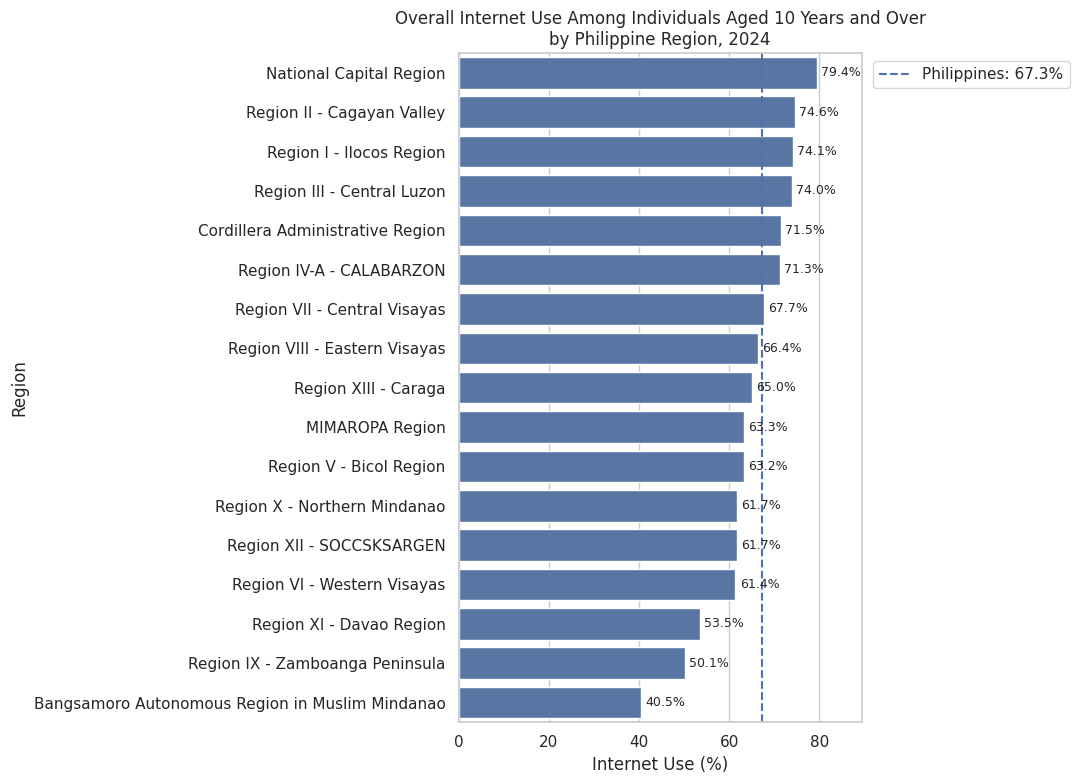

In [252]:
# @title
# ============================================================
# 11. VISUALIZE OVERALL INTERNET USE BY REGION
# ============================================================
# The chart answers:
#
# "How does overall internet use vary across Philippine regions?"
#
# A horizontal bar chart is used because the regional names are
# long and because ranking is important for this question.

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=regional_internet_use,
    x="Percentage",
    y="Region"
)

# Add the Philippine national percentage as a reference line.
# This makes it easy to see which regions fall above or below
# the national benchmark.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.5,
    label=f"Philippines: {national_percentage:.1f}%"
)

# Display the actual percentage beside every regional bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Overall Internet Use Among Individuals Aged 10 Years and Over\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Internet Use (%)")
plt.ylabel("Region")

# Place the national benchmark legend outside the plotting area
# so it does not cover the highest regional bar.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add space on the right so value labels are not cut off.
plt.xlim(
    0,
    regional_internet_use["Percentage"].max() + 10
)

plt.tight_layout()
plt.show()

In [253]:
# @title
# ============================================================
# 12. QUANTIFY THE REGIONAL INTERNET-USE PATTERN
# ============================================================
# The visualization shows the pattern visually.
#
# These calculations provide the exact evidence that can later
# be used when writing the Visualization Plan.

highest_region = regional_internet_use.iloc[0]
lowest_region = regional_internet_use.iloc[-1]

regional_gap = (
    highest_region["Percentage"]
    - lowest_region["Percentage"]
)

above_national = regional_internet_use[
    regional_internet_use["Percentage"] > national_percentage
]

below_national = regional_internet_use[
    regional_internet_use["Percentage"] < national_percentage
]

equal_national = regional_internet_use[
    regional_internet_use["Percentage"] == national_percentage
]

print("REGIONAL INTERNET-USE SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_region['Region']} "
    f"({highest_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_region['Region']} "
    f"({lowest_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{regional_gap:.1f} percentage points"
)

print(
    f"National benchmark: "
    f"{national_percentage:.1f}%"
)

print(
    f"Regions above national benchmark: "
    f"{len(above_national)}"
)

print(
    f"Regions below national benchmark: "
    f"{len(below_national)}"
)

print(
    f"Regions equal to national benchmark: "
    f"{len(equal_national)}"
)

REGIONAL INTERNET-USE SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (79.4%)
Lowest region: Bangsamoro Autonomous Region in Muslim Mindanao (40.5%)
Highest-to-lowest regional gap: 38.9 percentage points
National benchmark: 67.3%
Regions above national benchmark: 7
Regions below national benchmark: 10
Regions equal to national benchmark: 0


In [254]:
# @title
# ============================================================
# 13. DIFFERENCE FROM THE NATIONAL BENCHMARK
# ============================================================
# Calculate how far each region is above or below the national
# internet-use percentage.
#
# Positive value  -> above the Philippine benchmark
# Negative value  -> below the Philippine benchmark

regional_internet_use["Difference_from_National"] = (
    regional_internet_use["Percentage"]
    - national_percentage
)

benchmark_comparison = (
    regional_internet_use[
        [
            "Region",
            "Percentage",
            "Difference_from_National"
        ]
    ]
    .sort_values(
        "Difference_from_National",
        ascending=False
    )
    .reset_index(drop=True)
)

display(benchmark_comparison)

,Region,Percentage,Difference_from_National
0,National Capital Region,79.4,12.1
1,Region II - Cagayan Valley,74.6,7.3
2,Region I - Ilocos Region,74.1,6.8
3,Region III - Central Luzon,74.0,6.7
4,Cordillera Administrative Region,71.5,4.2
5,Region IV-A - CALABARZON,71.3,4.0
6,Region VII - Central Visayas,67.7,0.4
7,Region VIII - Eastern Visayas,66.4,-0.9
8,Region XIII - Caraga,65.0,-2.3
9,MIMAROPA Region,63.3,-4.0


### 4.4 Geographic Visualization Test

The regional bar chart clearly shows ranking and exact percentage differences, but the project's main analytical question is also geographic.

To test whether geographic location improves the communication of the insight, a choropleth map of the Philippines will be created using the same overall internet-use percentages.

The regional boundary file was derived from the project's Philippine SVG and grouped into the same 17 regional categories used by the PSA 2024 dataset.

The map will only be accepted if all 17 GeoJSON regions match the 17 PSA regional records with no missing values.

In [255]:
# @title
# ============================================================
# LOAD THE 17-REGION PHILIPPINES GEOJSON
# ============================================================
# GeoPandas allows geographic boundary files to be loaded and
# combined with the PSA regional data.
#
# The GeoJSON is stored in the same GitHub repository as the
# cleaned datasets so the Colab notebook remains reproducible.

!pip -q install geopandas

import geopandas as gpd

MAP_URL = (
    "https://raw.githubusercontent.com/"
    "Baelfyre/"
    "MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/"
    "main/"
    "philippines_regions_17.geojson"
)

ph_regions = gpd.read_file(MAP_URL)

print("GeoJSON loaded successfully.")
print(f"Map regions: {len(ph_regions)}")

display(
    ph_regions[
        ["Region", "Region_Code"]
    ].sort_values("Region")
)

GeoJSON loaded successfully.
Map regions: 17


,Region,Region_Code
16,Bangsamoro Autonomous Region in Muslim Mindanao,BARMM
1,Cordillera Administrative Region,CAR
6,MIMAROPA Region,17
0,National Capital Region,NCR
2,Region I - Ilocos Region,01
3,Region II - Cagayan Valley,02
4,Region III - Central Luzon,03
5,Region IV-A - CALABARZON,04
11,Region IX - Zamboanga Peninsula,09
7,Region V - Bicol Region,05


In [256]:
# @title
# ============================================================
# VALIDATE GEOJSON REGION NAMES AGAINST PSA DATA
# ============================================================
# A choropleth is only safe to create if every geographic region
# matches exactly one regional value from the PSA dataset.

map_regions = set(ph_regions["Region"])

psa_regions = set(
    regional_internet_use["Region"]
)

missing_from_map = psa_regions - map_regions
missing_from_data = map_regions - psa_regions

print("GEOGRAPHIC REGION VALIDATION")
print("-" * 60)

print(f"GeoJSON regions: {len(map_regions)}")
print(f"PSA regions: {len(psa_regions)}")

print(
    "PSA regions missing from map:",
    sorted(missing_from_map)
)

print(
    "Map regions missing from PSA data:",
    sorted(missing_from_data)
)

if (
    len(map_regions) == 17
    and len(psa_regions) == 17
    and len(missing_from_map) == 0
    and len(missing_from_data) == 0
):
    print("Geographic region validation: PASS")
else:
    print("Geographic region validation: CHECK")

GEOGRAPHIC REGION VALIDATION
------------------------------------------------------------
GeoJSON regions: 17
PSA regions: 17
PSA regions missing from map: []
Map regions missing from PSA data: []
Geographic region validation: PASS


In [257]:
# @title
# ============================================================
# MERGE OVERALL INTERNET USE WITH REGIONAL GEOMETRY
# ============================================================
# Each map region receives:
#
# Number     -> estimated number of internet users
# Percentage -> overall internet-use percentage
#
# Region is the shared key.

internet_map = ph_regions.merge(
    regional_internet_use[
        ["Region", "Number", "Percentage"]
    ],
    on="Region",
    how="left"
)

print("MAP + PSA MERGE VALIDATION")
print("-" * 60)

print(
    f"Rows after merge: "
    f"{len(internet_map)}"
)

print(
    f"Regions without Percentage: "
    f"{internet_map['Percentage'].isna().sum()}"
)

print(
    f"Regions without Number: "
    f"{internet_map['Number'].isna().sum()}"
)

if (
    len(internet_map) == 17
    and internet_map["Percentage"].isna().sum() == 0
    and internet_map["Number"].isna().sum() == 0
):
    print("Map-data merge: PASS")
else:
    print("Map-data merge: CHECK")

MAP + PSA MERGE VALIDATION
------------------------------------------------------------
Rows after merge: 17
Regions without Percentage: 0
Regions without Number: 0
Map-data merge: PASS


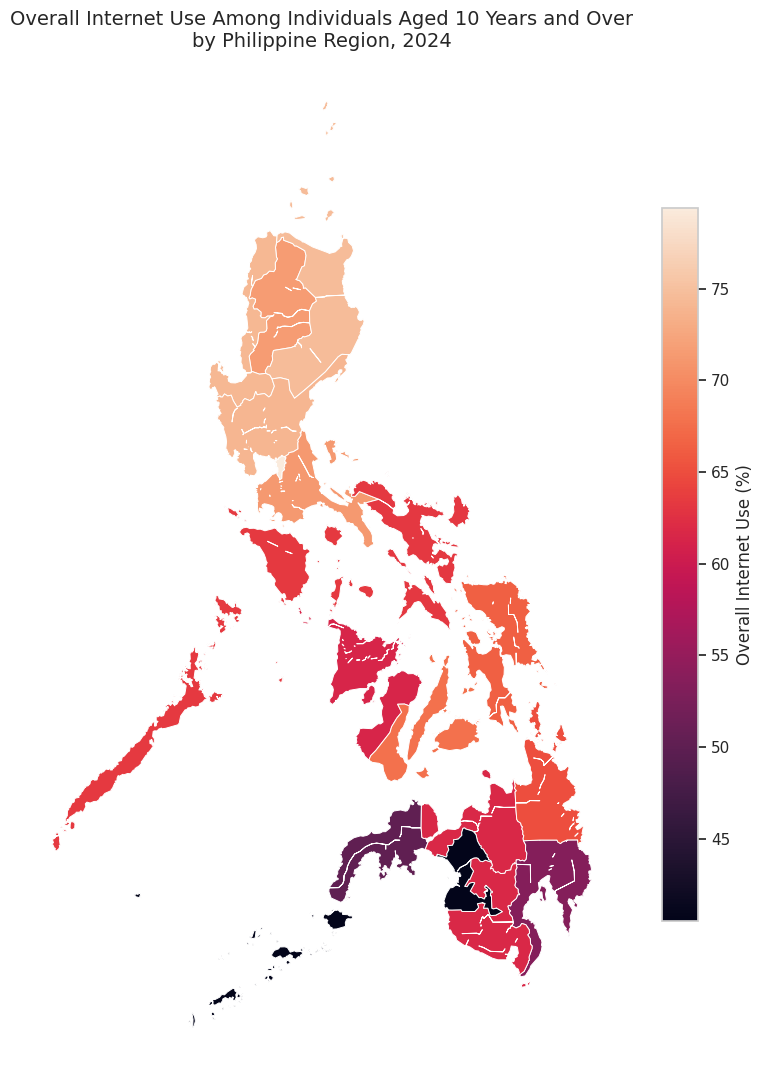

In [258]:
# @title
# ============================================================
# PHILIPPINES CHOROPLETH:
# OVERALL INTERNET USE BY REGION
# ============================================================
# The same Percentage measure used in the Q1 bar chart is mapped
# geographically.
#
# This lets us compare whether the map communicates the regional
# pattern more effectively than the ranked bar chart.

fig, ax = plt.subplots(
    figsize=(9, 11)
)

internet_map.plot(
    column="Percentage",
    ax=ax,
    legend=True,
    edgecolor="white",
    linewidth=0.7,
    legend_kwds={
        "label": "Overall Internet Use (%)",
        "shrink": 0.7
    }
)

ax.set_title(
    "Overall Internet Use Among Individuals Aged 10 Years and Over\n"
    "by Philippine Region, 2024",
    fontsize=14
)

# Geographic coordinate axes do not add useful information for
# the intended dashboard audience.
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [259]:
# @title
# ============================================================
# CLASSIFY REGIONS RELATIVE TO THE NATIONAL BENCHMARK
# ============================================================

internet_map["National_Benchmark_Status"] = np.where(
    internet_map["Percentage"] >= national_percentage,
    "At or Above National Benchmark",
    "Below National Benchmark"
)

benchmark_map_summary = (
    internet_map[
        "National_Benchmark_Status"
    ]
    .value_counts()
)

display(benchmark_map_summary)

,count
National_Benchmark_Status,
Below National Benchmark,10
At or Above National Benchmark,7


### Evidence

The exploratory analysis shows a substantial difference in overall internet use across Philippine regions.

- **Highest regional value:** National Capital Region at **79.4%**
- **Lowest regional value:** Bangsamoro Autonomous Region in Muslim Mindanao at **40.5%**
- **National benchmark:** **67.3%**
- **Highest-to-lowest regional gap:** **38.9 percentage points**
- **Regions above the national benchmark:** **7**
- **Regions below the national benchmark:** **10**
- **Regions equal to the national benchmark:** **0**

Compared with the national benchmark, the National Capital Region is **12.1 percentage points above** the Philippine value, while BARMM is **26.8 percentage points below** it.

The ranking also shows that the regional pattern is not limited to only the highest and lowest regions. Ten of the 17 regions fall below the national benchmark.

### Interpretation

Overall internet use varies substantially across Philippine regions.

The National Capital Region records the highest percentage at 79.4%, while BARMM records the lowest at 40.5%, producing a 38.9 percentage-point gap.

This provides evidence of a regional difference in internet use and supports the project's goal of identifying where digital-connectivity gaps may require closer examination.

However, this analysis only identifies **where the differences occur**. It does not explain why the regional differences exist.

Later analyses will examine other regional indicators, including device availability, network conditions, and internet-use frequency, to determine whether they show meaningful relationships with the overall internet-use pattern.

### Limitation

The data represents a regional snapshot for 2024.

The visualization identifies differences in internet use but does not establish what caused those differences.

Because the dataset contains only one year, it also cannot determine whether internet use in a region has increased or decreased over time.

Regional percentages should therefore be interpreted as comparative indicators rather than evidence of a trend or causal relationship.

### Preliminary Tableau Recommendation

**Candidate chart: Choropleth Map**

A choropleth map is a strong candidate for the final Tableau dashboard because the analytical question focuses on geographic differences across Philippine regions.

**Suggested Tableau Mapping**

- **Geography:** Region
- **Color:** Internet Use Percentage
- **Tooltip:** Region, Internet Use Percentage, Number of Internet Users
- **Reference information:** National benchmark of 67.3%

A **sorted horizontal bar chart** remains a useful alternative because it communicates exact rankings and percentage differences more precisely than a map.

The final choice should depend on the role of the visualization in the dashboard:

- use the **choropleth map** when geographic location is the main message
- use the **sorted bar chart** when precise regional comparison and ranking are more important

### Design Decisions

- Use a single sequential color scale for the choropleth map.
- Use consistent percentage formatting to one decimal place.
- Keep the 67.3% national benchmark visible in the chart context or tooltip.
- Avoid decorative or unrelated colors.
- Use complete regional names where space allows.
- Keep the focus on the percentage measure rather than raw population size.
- Use tooltips for supporting details instead of overcrowding the visualization with labels.

### Dashboard Role

**Primary Insight Candidate**

This visualization directly supports the project's main analytical purpose by showing where regional differences in internet use are present.

It establishes the baseline that later visualizations can use to examine possible related conditions.

### Decision

**KEEP**

The regional internet-use comparison provides a clear, evidence-supported baseline for the visualization plan and the future Tableau dashboard.

### 4.5 Visualization Comparison

The regional internet-use insight can be communicated using either a sorted horizontal bar chart or a choropleth map.

#### Sorted Horizontal Bar Chart

**Advantages**

- clearly shows exact regional ranking
- makes percentage differences easy to compare
- national benchmark can be shown precisely
- long region names remain readable

**Downsides**

- geographic location and spatial distribution are not visible
- does not emphasize the spatial nature of the project as strongly as a map

#### Choropleth Map

**Advantages**

- directly communicates the geographic distribution of internet use
- makes regional patterns easier to notice
- aligns well with the project's focus on Philippine regional connectivity
- provides an intuitive overview for mixed audiences

**Downsides**

- exact ranking is more difficult to judge from color alone
- geographically small regions may be visually less prominent
- precise values depend more on labels or tooltips

### Current Assessment

**Primary Candidate: Choropleth Map**

The choropleth is currently the strongest candidate for the main regional internet-use visualization because the analytical question focuses on **where** connectivity differences occur.

The sorted bar chart remains useful as an exploratory alternative when exact ranking is more important.

This is still subject to group review before the final Tableau dashboard is built.


# 5. Internet-Use Frequency by Region

## Analytical Question

**How does daily internet-use frequency vary across Philippine regions?**

## Purpose

Overall internet use tells us how widespread internet use is within a region, but it does not show how regularly people who use the internet go online.

This analysis examines **daily internet use** as an indicator of usage intensity.

The goal is to determine whether daily use is similarly distributed across regions or whether some regions have noticeably higher or lower levels of frequent internet use.

This adds another layer to the project's digital-connectivity story:

**Overall Internet Use → How many people use the internet**

**Daily Internet Use → How regularly internet users go online**

These measures should not be treated as the same indicator.

In [260]:
# @title
# ============================================================
# 14. VALIDATE THE INTERNET-USE FREQUENCY STRUCTURE
# ============================================================
# The Frequency dataset contains:
#
# Daily
# Weekly
# Monthly
# Not Regular
# Total
#
# "Total" represents overall internet use and is not itself a
# frequency category.
#
# The remaining categories describe how internet users are
# distributed according to frequency of use.
#
# We check whether Daily + Weekly + Monthly + Not Regular is
# approximately 100% for each geographic category.

frequency_categories = [
    "Daily",
    "Weekly",
    "Monthly",
    "Not Regular"
]

frequency_distribution = (
    df_frequency[
        df_frequency["Frequency"].isin(frequency_categories)
    ]
    .groupby("Region", as_index=False)["Percentage"]
    .sum()
    .rename(columns={
        "Percentage": "Frequency_Percentage_Total"
    })
)

# Difference from 100% helps identify small rounding differences
# in the original PSA data.
frequency_distribution["Difference_from_100"] = (
    frequency_distribution["Frequency_Percentage_Total"] - 100
)

display(
    frequency_distribution.sort_values(
        "Difference_from_100"
    )
)

print(
    "Minimum frequency total:",
    frequency_distribution["Frequency_Percentage_Total"].min()
)

print(
    "Maximum frequency total:",
    frequency_distribution["Frequency_Percentage_Total"].max()
)

,Region,Frequency_Percentage_Total,Difference_from_100
15,Region XI - Davao Region,99.9,-0.1
9,Region IX - Zamboanga Peninsula,99.9,-0.1
8,Region IV-A - CALABARZON,99.9,-0.1
10,Region V - Bicol Region,99.9,-0.1
11,Region VI - Western Visayas,99.9,-0.1
0,Bangsamoro Autonomous Region in Muslim Mindanao,100.0,0.0
2,MIMAROPA Region,100.0,0.0
1,Cordillera Administrative Region,100.0,0.0
3,National Capital Region,100.0,0.0
12,Region VII - Central Visayas,100.0,0.0


Minimum frequency total: 99.89999999999999
Maximum frequency total: 100.10000000000001


### 5.1 Daily Internet Use

The `Daily` category will be isolated to compare the share of internet users who report using the internet every day.

As with the previous analysis, the `PHILIPPINES` record will be treated as the national benchmark rather than as another region.

Percentage will be used instead of Number because the goal is to compare usage frequency across regions with different population sizes.

In [261]:
# @title
# ============================================================
# 15. PREPARE DAILY INTERNET USE BY REGION
# ============================================================

daily_use = (
    df_frequency[
        df_frequency["Frequency"] == "Daily"
    ]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the Philippine national value.
daily_national_row = daily_use[
    daily_use["Region"] == "PHILIPPINES"
].iloc[0]

daily_national_number = daily_national_row["Number"]
daily_national_percentage = daily_national_row["Percentage"]

# Keep the 17 regions for comparison.
regional_daily_use = (
    daily_use[
        daily_use["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("DAILY INTERNET-USE BASELINE")
print("-" * 60)

print(
    f"Philippines daily internet users: "
    f"{daily_national_number:,.0f}"
)

print(
    f"National daily-use percentage: "
    f"{daily_national_percentage:.1f}%"
)

print(
    f"Number of regions compared: "
    f"{len(regional_daily_use)}"
)

display(regional_daily_use)

DAILY INTERNET-USE BASELINE
------------------------------------------------------------
Philippines daily internet users: 47,253,389
National daily-use percentage: 76.9%
Number of regions compared: 17


,Region,Number,Percentage
0,National Capital Region,8618211,91.0
1,Region III - Central Luzon,6292391,79.4
2,Region I - Ilocos Region,2563353,78.9
3,Region IV-A - CALABARZON,7834961,78.6
4,Region VII - Central Visayas,3528447,78.2
5,Region VI - Western Visayas,3081031,76.1
6,Region XI - Davao Region,1787032,75.1
7,Region VIII - Eastern Visayas,1901840,74.1
8,Region II - Cagayan Valley,1684190,73.9
9,Cordillera Administrative Region,770450,72.0


### 5.2 Exploratory Visualization

A **sorted horizontal bar chart** is used first to compare daily internet-use percentages across regions.

This chart is appropriate for the exploratory stage because:

- the analytical question requires comparison across multiple regions
- sorting makes the strongest and weakest daily-use levels easy to identify
- horizontal bars provide enough room for complete regional names
- the national percentage can be displayed as a reference benchmark

The purpose of this chart is to determine whether the regional differences are substantial enough to justify inclusion in the final Tableau dashboard.

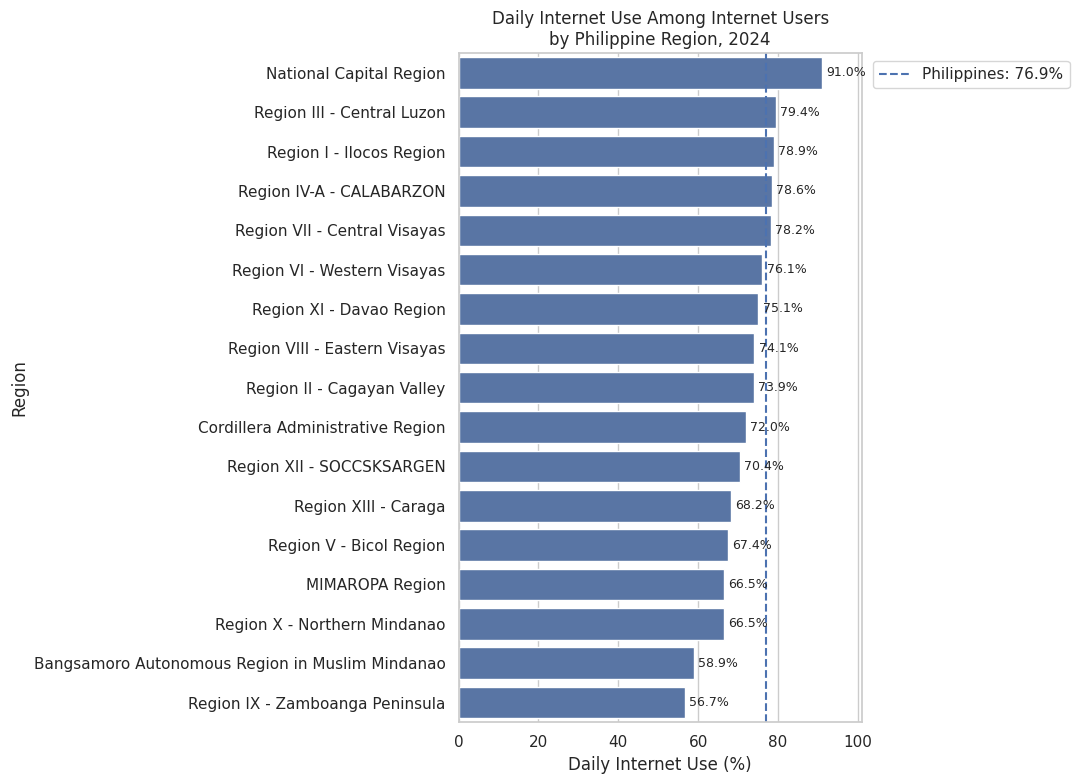

In [262]:
# @title
# ============================================================
# 16. VISUALIZE DAILY INTERNET USE BY REGION
# ============================================================

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=regional_daily_use,
    x="Percentage",
    y="Region"
)

# National daily-use benchmark.
plt.axvline(
    daily_national_percentage,
    linestyle="--",
    linewidth=1.5,
    label=f"Philippines: {daily_national_percentage:.1f}%"
)

# Display percentage values.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Daily Internet Use Among Internet Users\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Daily Internet Use (%)")
plt.ylabel("Region")

# Keep the legend away from the bars.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.xlim(
    0,
    regional_daily_use["Percentage"].max() + 10
)

plt.tight_layout()
plt.show()

In [263]:
# @title
# ============================================================
# 17. SUMMARIZE DAILY INTERNET-USE DIFFERENCES
# ============================================================

highest_daily_region = regional_daily_use.iloc[0]
lowest_daily_region = regional_daily_use.iloc[-1]

daily_regional_gap = (
    highest_daily_region["Percentage"]
    - lowest_daily_region["Percentage"]
)

daily_above_national = regional_daily_use[
    regional_daily_use["Percentage"]
    > daily_national_percentage
]

daily_below_national = regional_daily_use[
    regional_daily_use["Percentage"]
    < daily_national_percentage
]

daily_equal_national = regional_daily_use[
    regional_daily_use["Percentage"]
    == daily_national_percentage
]

print("DAILY INTERNET-USE SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_daily_region['Region']} "
    f"({highest_daily_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_daily_region['Region']} "
    f"({lowest_daily_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{daily_regional_gap:.1f} percentage points"
)

print(
    f"National daily-use percentage: "
    f"{daily_national_percentage:.1f}%"
)

print(
    f"Regions above national level: "
    f"{len(daily_above_national)}"
)

print(
    f"Regions below national level: "
    f"{len(daily_below_national)}"
)

print(
    f"Regions equal to national level: "
    f"{len(daily_equal_national)}"
)

DAILY INTERNET-USE SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (91.0%)
Lowest region: Region IX - Zamboanga Peninsula (56.7%)
Highest-to-lowest regional gap: 34.3 percentage points
National daily-use percentage: 76.9%
Regions above national level: 5
Regions below national level: 12
Regions equal to national level: 0


In [264]:
# @title
# ============================================================
# 18. COMPARE DAILY USE WITH THE NATIONAL BENCHMARK
# ============================================================

regional_daily_use["Difference_from_National"] = (
    regional_daily_use["Percentage"]
    - daily_national_percentage
)

daily_benchmark_comparison = (
    regional_daily_use[
        [
            "Region",
            "Percentage",
            "Difference_from_National"
        ]
    ]
    .sort_values(
        "Difference_from_National",
        ascending=False
    )
    .reset_index(drop=True)
)

display(daily_benchmark_comparison)

,Region,Percentage,Difference_from_National
0,National Capital Region,91.0,14.1
1,Region III - Central Luzon,79.4,2.5
2,Region I - Ilocos Region,78.9,2.0
3,Region IV-A - CALABARZON,78.6,1.7
4,Region VII - Central Visayas,78.2,1.3
5,Region VI - Western Visayas,76.1,-0.8
6,Region XI - Davao Region,75.1,-1.8
7,Region VIII - Eastern Visayas,74.1,-2.8
8,Region II - Cagayan Valley,73.9,-3.0
9,Cordillera Administrative Region,72.0,-4.9


### Evidence

The frequency categories sum to approximately 100% for every geographic category, ranging from **99.9% to 100.1%**.

The small differences from 100% are consistent with rounding in the source data. This supports interpreting Daily, Weekly, Monthly, and Not Regular as the distribution of internet users by frequency of use.

For daily internet use:

- **Highest regional value:** National Capital Region at **91.0%**
- **Lowest regional value:** Region IX - Zamboanga Peninsula at **56.7%**
- **National benchmark:** **76.9%**
- **Highest-to-lowest regional gap:** **34.3 percentage points**
- **Regions above the national benchmark:** **5**
- **Regions below the national benchmark:** **12**
- **Regions equal to the national benchmark:** **0**

NCR is **14.1 percentage points above** the national daily-use benchmark.

Zamboanga Peninsula is **20.2 percentage points below** the national benchmark, while BARMM is **18.0 percentage points below** it.

### Interpretation

Daily internet use also varies considerably across Philippine regions.

However, the ranking is not identical to the overall internet-use ranking.

For example, Cagayan Valley has one of the highest overall internet-use percentages, but its daily-use percentage falls below the national daily-use benchmark.

Davao Region shows a different pattern. Its overall internet-use percentage is substantially below the national level, while its daily-use percentage among internet users is much closer to the national daily-use benchmark.

This indicates that **internet reach and frequency of use are related but are not the same measure**.

A region may have relatively limited overall internet use while the people who are already connected still use the internet frequently.

### Limitation

Daily-use percentage describes frequency among the internet users represented in the dataset.

It should not be interpreted as the percentage of the entire regional population that uses the internet every day.

The analysis also does not explain why frequency differs between regions.

### Visualization Assessment

The daily-use comparison contains useful information, but a standalone regional chart would partly repeat the regional-comparison structure already used for overall internet use.

Its stronger analytical value is to compare daily-use frequency directly with overall internet use.

### Possible Dashboard Role

**Supporting Measure / Input to Cross-Dataset Analysis**

Rather than using another large regional map, daily internet use should be carried forward into a relationship visualization that compares **internet reach** with **usage frequency**.

### Current Assessment

**REVISE / COMBINE**

For now, retain the daily-use measure and test it together with overall internet use rather than treating the standalone regional chart as a final dashboard choice.


# 6. Overall Internet Use vs Daily Internet Use

## Analytical Question

**Do regions with higher overall internet use also tend to have a higher share of daily internet users?**

## Purpose

The previous analyses measured two different aspects of digital connectivity:

- **Overall Internet Use** describes how widespread internet use is within a region.
- **Daily Internet Use** describes how frequently recorded internet users go online.

Comparing these indicators can help determine whether regions with broader internet use also tend to have more frequent internet use.

This distinction is important because **reach and usage frequency are not the same condition**.

A region may have:

- high overall use and high daily use
- high overall use but lower daily use
- lower overall use but relatively frequent use among those already connected
- lower levels on both measures

This analysis therefore moves from simple regional ranking toward examining the relationship between two dimensions of digital connectivity.

In [265]:
# @title
# ============================================================
# 19. COMBINE OVERALL INTERNET USE AND DAILY INTERNET USE
# ============================================================
# Both datasets contain one relevant value per Region after
# filtering:
#
# Overall Internet Use -> Both Sexes Percentage
# Daily Internet Use   -> Daily Percentage
#
# Joining on Region is valid because each filtered dataset now
# has one observation per geographic category.

reach_frequency = (
    regional_internet_use[
        ["Region", "Percentage"]
    ]
    .rename(columns={
        "Percentage": "Overall_Internet_Use"
    })
    .merge(
        regional_daily_use[
            ["Region", "Percentage"]
        ].rename(columns={
            "Percentage": "Daily_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(
    reach_frequency.sort_values(
        "Overall_Internet_Use",
        ascending=False
    )
)

print(
    "Regions successfully matched:",
    len(reach_frequency)
)

,Region,Overall_Internet_Use,Daily_Internet_Use
0,National Capital Region,79.4,91.0
1,Region II - Cagayan Valley,74.6,73.9
2,Region I - Ilocos Region,74.1,78.9
3,Region III - Central Luzon,74.0,79.4
4,Cordillera Administrative Region,71.5,72.0
5,Region IV-A - CALABARZON,71.3,78.6
6,Region VII - Central Visayas,67.7,78.2
7,Region VIII - Eastern Visayas,66.4,74.1
8,Region XIII - Caraga,65.0,68.2
9,MIMAROPA Region,63.3,66.5


Regions successfully matched: 17


In [266]:
# @title
# ============================================================
# 20. VALIDATE THE REGION-LEVEL JOIN
# ============================================================
# A valid analytical join should retain exactly one record for
# each of the 17 Philippine regions.

duplicate_regions = reach_frequency["Region"].duplicated().sum()
missing_values = reach_frequency.isna().sum().sum()

print("JOIN VALIDATION")
print("-" * 60)

print(
    f"Rows after join: "
    f"{len(reach_frequency)}"
)

print(
    f"Duplicate regions: "
    f"{duplicate_regions}"
)

print(
    f"Missing values: "
    f"{missing_values}"
)

if (
    len(reach_frequency) == 17
    and duplicate_regions == 0
    and missing_values == 0
):
    print("Join validation: PASS")
else:
    print("Join validation: CHECK")

JOIN VALIDATION
------------------------------------------------------------
Rows after join: 17
Duplicate regions: 0
Missing values: 0
Join validation: PASS


### 6.1 Exploratory Visualization

A **scatter plot** is appropriate because the analytical question concerns the relationship between two quantitative regional indicators.

Each point represents one Philippine region.

- **X-axis:** Overall Internet Use (%)
- **Y-axis:** Daily Internet Use (%)

National benchmarks are added as reference lines:

- Overall Internet Use: **67.3%**
- Daily Internet Use: **76.9%**

These reference lines divide the chart into four analytical areas and make it easier to distinguish regions with different combinations of internet reach and usage frequency.

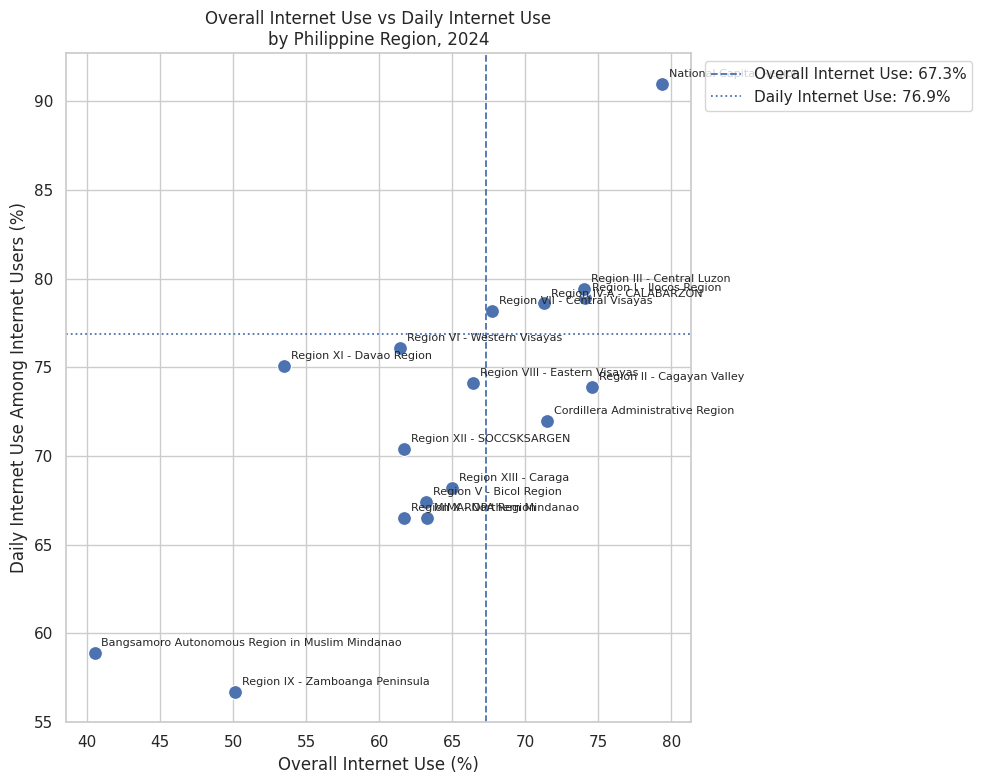

In [267]:
# @title
# ============================================================
# 21. VISUALIZE INTERNET REACH VS DAILY USE
# ============================================================

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=reach_frequency,
    x="Overall_Internet_Use",
    y="Daily_Internet_Use",
    s=100
)

# National reference lines.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.3,
    label=f"Overall Internet Use: {national_percentage:.1f}%"
)

plt.axhline(
    daily_national_percentage,
    linestyle=":",
    linewidth=1.3,
    label=f"Daily Internet Use: {daily_national_percentage:.1f}%"
)

# Label every regional point.
for _, row in reach_frequency.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Overall_Internet_Use"],
            row["Daily_Internet_Use"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(
    "Overall Internet Use vs Daily Internet Use\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Overall Internet Use (%)")
plt.ylabel("Daily Internet Use Among Internet Users (%)")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

In [268]:
# @title
# ============================================================
# 22. DESCRIBE THE RELATIONSHIP BETWEEN THE TWO INDICATORS
# ============================================================
# Pearson correlation summarizes how closely the two regional
# indicators move together.
#
# This is used here as descriptive support for the visualization.
# It does not establish causation.

correlation = reach_frequency[
    [
        "Overall_Internet_Use",
        "Daily_Internet_Use"
    ]
].corr().iloc[0, 1]

print(
    f"Pearson correlation: "
    f"{correlation:.3f}"
)

Pearson correlation: 0.792


In [269]:
# @title
# ============================================================
# 23. CLASSIFY REGIONS USING THE NATIONAL BENCHMARKS
# ============================================================
# The two national reference values create four possible
# combinations:
#
# High Reach + High Daily Use
# High Reach + Lower Daily Use
# Lower Reach + High Daily Use
# Lower Reach + Lower Daily Use

def classify_region(row):

    high_reach = (
        row["Overall_Internet_Use"]
        >= national_percentage
    )

    high_daily = (
        row["Daily_Internet_Use"]
        >= daily_national_percentage
    )

    if high_reach and high_daily:
        return "High Reach / High Daily Use"

    elif high_reach and not high_daily:
        return "High Reach / Lower Daily Use"

    elif not high_reach and high_daily:
        return "Lower Reach / High Daily Use"

    else:
        return "Lower Reach / Lower Daily Use"


reach_frequency["Connectivity_Profile"] = (
    reach_frequency.apply(
        classify_region,
        axis=1
    )
)

profile_summary = (
    reach_frequency[
        "Connectivity_Profile"
    ]
    .value_counts()
    .rename_axis("Connectivity Profile")
    .reset_index(name="Regions")
)

display(profile_summary)

,Connectivity Profile,Regions
0,Lower Reach / Lower Daily Use,10
1,High Reach / High Daily Use,5
2,High Reach / Lower Daily Use,2


In [270]:
# @title
# ============================================================
# 25. ADD INTERNET-USER POPULATION FOR BUBBLE SIZE
# ============================================================
# Number of Internet Users will be used only to represent
# population scale through bubble size.
#
# It is NOT treated as a measure of connectivity performance.

internet_user_count = (
    regional_internet_use[
        ["Region", "Number"]
    ]
    .rename(columns={
        "Number": "Internet_Users"
    })
)

reach_frequency = reach_frequency.merge(
    internet_user_count,
    on="Region",
    how="left"
)

display(
    reach_frequency[
        [
            "Region",
            "Overall_Internet_Use",
            "Daily_Internet_Use",
            "Internet_Users",
            "Connectivity_Profile"
        ]
    ]
)

,Region,Overall_Internet_Use,Daily_Internet_Use,Internet_Users,Connectivity_Profile
0,National Capital Region,79.4,91.0,9465688,High Reach / High Daily Use
1,Region II - Cagayan Valley,74.6,73.9,2280119,High Reach / Lower Daily Use
2,Region I - Ilocos Region,74.1,78.9,3250486,High Reach / High Daily Use
3,Region III - Central Luzon,74.0,79.4,7920256,High Reach / High Daily Use
4,Cordillera Administrative Region,71.5,72.0,1070014,High Reach / Lower Daily Use
5,Region IV-A - CALABARZON,71.3,78.6,9966173,High Reach / High Daily Use
6,Region VII - Central Visayas,67.7,78.2,4514738,High Reach / High Daily Use
7,Region VIII - Eastern Visayas,66.4,74.1,2565585,Lower Reach / Lower Daily Use
8,Region XIII - Caraga,65.0,68.2,1442671,Lower Reach / Lower Daily Use
9,MIMAROPA Region,63.3,66.5,1607108,Lower Reach / Lower Daily Use


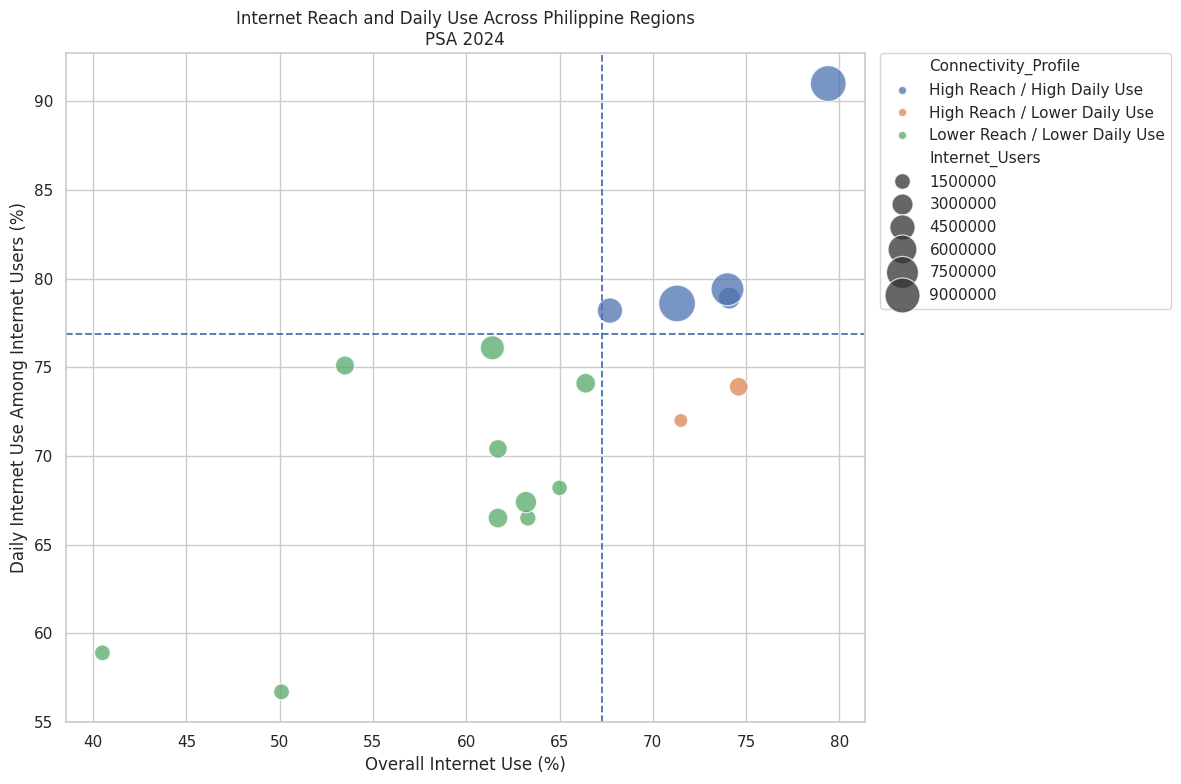

In [271]:
# @title
# ============================================================
# 26. BUBBLE SCATTER:
#     INTERNET REACH VS DAILY USE
# ============================================================
# X position:
#   Overall Internet Use %
#
# Y position:
#   Daily Internet Use %
#
# Bubble size:
#   Number of Internet Users
#
# Bubble category:
#   Connectivity Profile based on national benchmarks.
#
# Bubble size provides population context only and should not
# be interpreted as connectivity performance.

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=reach_frequency,
    x="Overall_Internet_Use",
    y="Daily_Internet_Use",
    size="Internet_Users",
    hue="Connectivity_Profile",

    # Keep the bubble-size range controlled so highly populated
    # regions do not overwhelm the visualization.
    sizes=(100, 700),

    alpha=0.75
)

# National benchmarks divide the chart into four analytical areas.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.3
)

plt.axhline(
    daily_national_percentage,
    linestyle="--",
    linewidth=1.3
)

plt.title(
    "Internet Reach and Daily Use Across Philippine Regions\n"
    "PSA 2024"
)

plt.xlabel("Overall Internet Use (%)")
plt.ylabel("Daily Internet Use Among Internet Users (%)")

# Move the legend outside the plotting area.
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Evidence

The comparison shows a positive relationship between overall internet use and daily internet-use frequency across Philippine regions.

The Pearson correlation between the two regional indicators is approximately **0.792**, indicating that regions with higher overall internet use generally also tend to have a higher share of daily internet users.

Using the Philippine benchmarks of **67.3% overall internet use** and **76.9% daily internet use**, the regions are distributed across three observed connectivity profiles:

- **5 regions:** High Reach / High Daily Use
- **2 regions:** High Reach / Lower Daily Use
- **10 regions:** Lower Reach / Lower Daily Use
- **0 regions:** Lower Reach / High Daily Use

No region with below-national overall internet use exceeds the national daily-use benchmark.

### Interpretation

The results suggest that broader internet reach is generally associated with more frequent internet use.

However, the relationship is not identical across regions.

Some regions, such as Cagayan Valley and the Cordillera Administrative Region, have overall internet-use percentages above the national benchmark but daily-use percentages below the national daily-use benchmark.

This shows that **internet reach and usage intensity describe different aspects of digital connectivity**.

A region can have relatively broad internet use without necessarily having an equally high level of daily use.

### Limitation

The observed relationship is an association between regional indicators and should not be interpreted as causal.

The analysis does not establish that higher internet reach causes more frequent internet use or identify the factors responsible for the relationship.

Bubble size represents the number of internet users in each region and provides population context only. It should not be interpreted as a measure of connectivity performance.

### Candidate Visualization Assessment

**Candidate visualization: Bubble Scatter Plot with Benchmark Quadrants**

Suggested mapping:

- **X-axis:** Overall Internet Use %
- **Y-axis:** Daily Internet Use %
- **Bubble Size:** Number of Internet Users
- **Color:** Connectivity Profile
- **Detail:** Region
- **Reference Line X:** Philippines Overall Internet Use = 67.3%
- **Reference Line Y:** Philippines Daily Internet Use = 76.9%
- **Tooltip:** Region, Overall Internet Use %, Daily Internet Use %, Number of Internet Users, Connectivity Profile

### Design Decisions

- Use the national benchmarks to create four analytical quadrants.
- Use restrained colors to distinguish connectivity profiles.
- Use bubble size only for population context.
- Format internet-user counts using compact values such as millions.
- Avoid labeling every bubble directly.
- Use tooltips for full regional details.
- Label only selected regions when they illustrate an important exception or pattern.
- Keep the X and Y percentage scales clearly labeled.

### Possible Dashboard Role

**Primary Insight**

This visualization extends the regional comparison by showing how internet reach and usage frequency relate to each other.

It helps move the dashboard narrative from **where regional differences exist** to **how different dimensions of connectivity interact**.

### Current Assessment

**Strong Candidate**

The bubble scatter plot provides a distinct analytical insight and is currently stronger than presenting daily internet use as another standalone regional ranking. Final inclusion remains subject to group review.


# 7. Working Device Access and Overall Internet Use

## Analytical Question

**Do regions with higher access to working communication devices also tend to report higher overall internet use?**

## Purpose

The previous analyses showed that internet use and daily-use frequency differ across Philippine regions.

This section examines a possible connectivity condition associated with those differences: access to a device that is working, has an active SIM, and is used for communication.

The comparison helps determine whether regions with greater working-device access also tend to have higher overall internet use.

This analysis does not assume that device access causes internet use. It only examines whether the two regional indicators show a meaningful relationship.

## Variables

### Overall Internet Use

From the Gender dataset:

- **Region**
- **Gender:** `Both Sexes`
- **Percentage:** Overall Internet Use %

### Working Device Access

From the Network / Device / Signal dataset:

- **Region**
- **Network / Device / Signal:** `Working Device`
- **Percentage:** Working Device %

The two datasets will be combined using **Region** after each has been reduced to one observation per geographic category.



In [272]:
# @title
# ============================================================
# 27. PREPARE WORKING-DEVICE ACCESS BY REGION
# ============================================================
# "Working Device" represents individuals aged 10 years and over
# with a device that is working, has an active SIM, and is used
# for communication.
#
# We first isolate this category before performing any
# cross-dataset comparison.

working_device = (
    df_network[
        df_network["Network / Device / Signal"] == "Working Device"
    ]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the Philippines total from the regional observations.
working_device_national = working_device[
    working_device["Region"] == "PHILIPPINES"
].iloc[0]

working_device_national_number = working_device_national["Number"]
working_device_national_percentage = working_device_national["Percentage"]

regional_working_device = (
    working_device[
        working_device["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("WORKING-DEVICE ACCESS BASELINE")
print("-" * 60)

print(
    f"Philippines working-device count: "
    f"{working_device_national_number:,.0f}"
)

print(
    f"National working-device percentage: "
    f"{working_device_national_percentage:.1f}%"
)

print(
    f"Number of regions compared: "
    f"{len(regional_working_device)}"
)

display(regional_working_device)

WORKING-DEVICE ACCESS BASELINE
------------------------------------------------------------
Philippines working-device count: 72,935,183
National working-device percentage: 79.8%
Number of regions compared: 17


,Region,Number,Percentage
0,National Capital Region,10962747,92.0
1,Region IV-A - CALABARZON,12080181,86.4
2,Cordillera Administrative Region,1273832,85.1
3,Region III - Central Luzon,9030614,84.3
4,Region I - Ilocos Region,3678324,83.8
5,Region II - Cagayan Valley,2434114,79.7
6,Region VII - Central Visayas,5285418,79.3
7,Region X - Northern Mindanao,3203448,76.7
8,Region XIII - Caraga,1687377,76.0
9,Region VI - Western Visayas,4992329,75.8


In [273]:
# @title
# ============================================================
# 28. SUMMARIZE REGIONAL WORKING-DEVICE ACCESS
# ============================================================

highest_device_region = regional_working_device.iloc[0]
lowest_device_region = regional_working_device.iloc[-1]

device_gap = (
    highest_device_region["Percentage"]
    - lowest_device_region["Percentage"]
)

device_above_national = regional_working_device[
    regional_working_device["Percentage"]
    > working_device_national_percentage
]

device_below_national = regional_working_device[
    regional_working_device["Percentage"]
    < working_device_national_percentage
]

device_equal_national = regional_working_device[
    regional_working_device["Percentage"]
    == working_device_national_percentage
]

print("WORKING-DEVICE ACCESS SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_device_region['Region']} "
    f"({highest_device_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_device_region['Region']} "
    f"({lowest_device_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{device_gap:.1f} percentage points"
)

print(
    f"National benchmark: "
    f"{working_device_national_percentage:.1f}%"
)

print(
    f"Regions above national benchmark: "
    f"{len(device_above_national)}"
)

print(
    f"Regions below national benchmark: "
    f"{len(device_below_national)}"
)

print(
    f"Regions equal to national benchmark: "
    f"{len(device_equal_national)}"
)

WORKING-DEVICE ACCESS SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (92.0%)
Lowest region: Region IX - Zamboanga Peninsula (66.2%)
Highest-to-lowest regional gap: 25.8 percentage points
National benchmark: 79.8%
Regions above national benchmark: 5
Regions below national benchmark: 12
Regions equal to national benchmark: 0


### 7.3 Cross-Dataset Combination

Both datasets have been reduced to one percentage value per region:

- Overall Internet Use %
- Working Device %

This allows a one-to-one regional comparison using `Region` as the common field.

The join will be validated before the relationship is analyzed.

In [274]:
# @title
# ============================================================
# 29. COMBINE WORKING-DEVICE ACCESS WITH INTERNET USE
# ============================================================

device_internet = (
    regional_working_device[
        ["Region", "Number", "Percentage"]
    ]
    .rename(columns={
        "Number": "Working_Device_Number",
        "Percentage": "Working_Device_Percentage"
    })
    .merge(
        regional_internet_use[
            ["Region", "Number", "Percentage"]
        ].rename(columns={
            "Number": "Internet_Users",
            "Percentage": "Overall_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(
    device_internet.sort_values(
        "Overall_Internet_Use",
        ascending=False
    )
)

,Region,Working_Device_Number,Working_Device_Percentage,Internet_Users,Overall_Internet_Use
0,National Capital Region,10962747,92.0,9465688,79.4
5,Region II - Cagayan Valley,2434114,79.7,2280119,74.6
4,Region I - Ilocos Region,3678324,83.8,3250486,74.1
3,Region III - Central Luzon,9030614,84.3,7920256,74.0
2,Cordillera Administrative Region,1273832,85.1,1070014,71.5
1,Region IV-A - CALABARZON,12080181,86.4,9966173,71.3
6,Region VII - Central Visayas,5285418,79.3,4514738,67.7
13,Region VIII - Eastern Visayas,2700906,69.9,2565585,66.4
8,Region XIII - Caraga,1687377,76.0,1442671,65.0
10,MIMAROPA Region,1896311,74.7,1607108,63.3


In [275]:
# @title
# ============================================================
# 30. VALIDATE THE DEVICE + INTERNET JOIN
# ============================================================

device_join_duplicates = (
    device_internet["Region"]
    .duplicated()
    .sum()
)

device_join_missing = (
    device_internet
    .isna()
    .sum()
    .sum()
)

print("JOIN VALIDATION")
print("-" * 60)

print(
    f"Rows after join: "
    f"{len(device_internet)}"
)

print(
    f"Duplicate regions: "
    f"{device_join_duplicates}"
)

print(
    f"Missing values: "
    f"{device_join_missing}"
)

if (
    len(device_internet) == 17
    and device_join_duplicates == 0
    and device_join_missing == 0
):
    print("Join validation: PASS")
else:
    print("Join validation: CHECK")

JOIN VALIDATION
------------------------------------------------------------
Rows after join: 17
Duplicate regions: 0
Missing values: 0
Join validation: PASS


### 7.5 Exploratory Visualization

A **scatter plot** is used because the analytical question examines the relationship between two quantitative regional indicators.

- **X-axis:** Working Device Access %
- **Y-axis:** Overall Internet Use %

Each point represents one Philippine region.

National reference lines are included to help identify regions that are above or below the Philippine benchmarks for both indicators.

The purpose is to determine whether working-device availability shows a meaningful regional relationship with overall internet use.

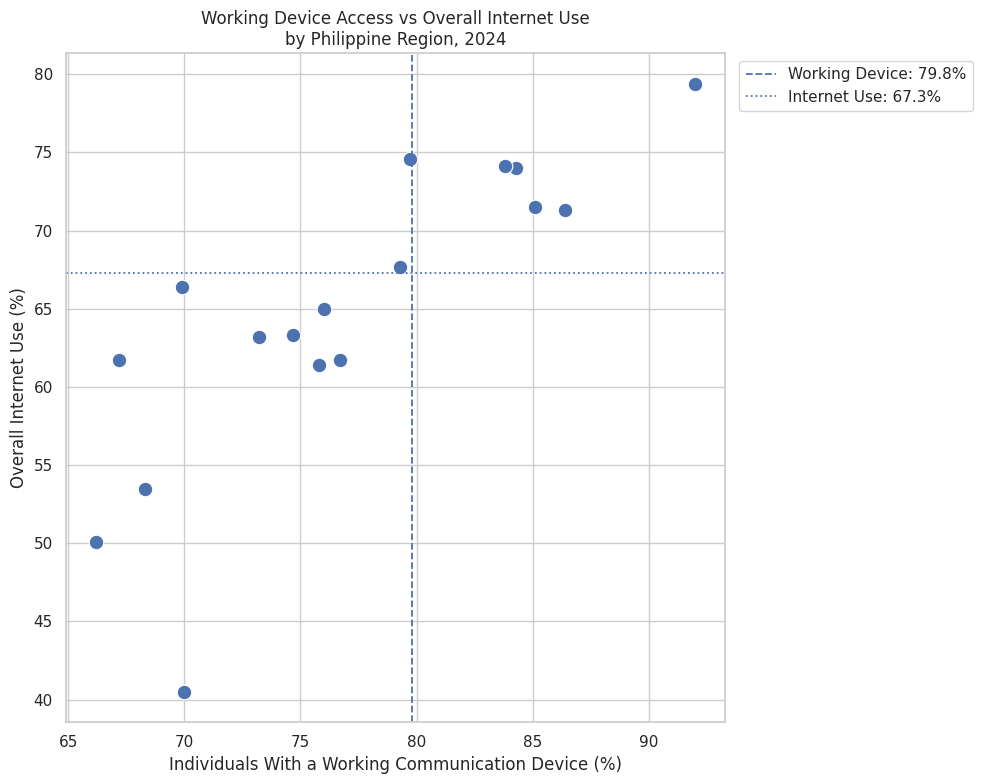

In [276]:
# @title
# ============================================================
# 31. VISUALIZE WORKING-DEVICE ACCESS VS INTERNET USE
# ============================================================

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=device_internet,
    x="Working_Device_Percentage",
    y="Overall_Internet_Use",
    s=110
)

# National device benchmark.
plt.axvline(
    working_device_national_percentage,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"Working Device: "
        f"{working_device_national_percentage:.1f}%"
    )
)

# National internet-use benchmark.
plt.axhline(
    national_percentage,
    linestyle=":",
    linewidth=1.3,
    label=(
        f"Internet Use: "
        f"{national_percentage:.1f}%"
    )
)

plt.title(
    "Working Device Access vs Overall Internet Use\n"
    "by Philippine Region, 2024"
)

plt.xlabel(
    "Individuals With a Working Communication Device (%)"
)

plt.ylabel(
    "Overall Internet Use (%)"
)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

In [277]:
# @title
# ============================================================
# 32. DESCRIBE THE DEVICE-INTERNET RELATIONSHIP
# ============================================================
# Pearson correlation summarizes how closely the regional
# percentages move together.
#
# It is used descriptively here and does not establish causation.

device_internet_correlation = (
    device_internet[
        [
            "Working_Device_Percentage",
            "Overall_Internet_Use"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Pearson correlation: "
    f"{device_internet_correlation:.3f}"
)

Pearson correlation: 0.811


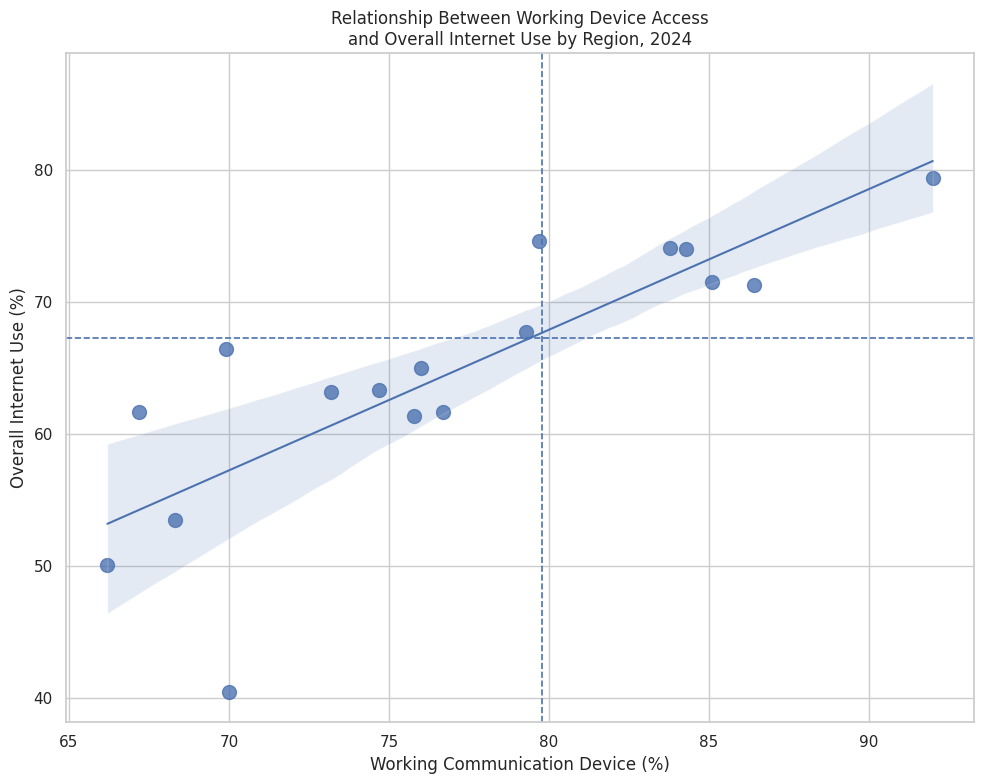

In [278]:
# @title
# ============================================================
# 33. ADD AN EXPLORATORY TREND LINE
# ============================================================
# The regression line helps us inspect the overall direction
# of the regional relationship.
#
# It should not be interpreted as evidence that device access
# causes internet use.

plt.figure(figsize=(10, 8))

sns.regplot(
    data=device_internet,
    x="Working_Device_Percentage",
    y="Overall_Internet_Use",
    scatter_kws={
        "s": 100,
        "alpha": 0.8
    },
    line_kws={
        "linewidth": 1.5
    }
)

plt.axvline(
    working_device_national_percentage,
    linestyle="--",
    linewidth=1.2
)

plt.axhline(
    national_percentage,
    linestyle="--",
    linewidth=1.2
)

plt.title(
    "Relationship Between Working Device Access\n"
    "and Overall Internet Use by Region, 2024"
)

plt.xlabel(
    "Working Communication Device (%)"
)

plt.ylabel(
    "Overall Internet Use (%)"
)

plt.tight_layout()
plt.show()

In [279]:
# @title
# ============================================================
# 34. CLASSIFY DEVICE + INTERNET CONNECTIVITY PROFILES
# ============================================================

def classify_device_profile(row):

    high_device = (
        row["Working_Device_Percentage"]
        >= working_device_national_percentage
    )

    high_internet = (
        row["Overall_Internet_Use"]
        >= national_percentage
    )

    if high_device and high_internet:
        return "High Device / High Internet Use"

    elif high_device and not high_internet:
        return "High Device / Lower Internet Use"

    elif not high_device and high_internet:
        return "Lower Device / High Internet Use"

    else:
        return "Lower Device / Lower Internet Use"


device_internet["Device_Internet_Profile"] = (
    device_internet.apply(
        classify_device_profile,
        axis=1
    )
)

device_profile_summary = (
    device_internet[
        "Device_Internet_Profile"
    ]
    .value_counts()
    .rename_axis("Device / Internet Profile")
    .reset_index(name="Regions")
)

display(device_profile_summary)

,Device / Internet Profile,Regions
0,Lower Device / Lower Internet Use,10
1,High Device / High Internet Use,5
2,Lower Device / High Internet Use,2


In [280]:
# @title
# ============================================================
# 35. REVIEW REGIONS BY DEVICE + INTERNET PROFILE
# ============================================================

device_profile_detail = (
    device_internet[
        [
            "Region",
            "Working_Device_Percentage",
            "Overall_Internet_Use",
            "Device_Internet_Profile"
        ]
    ]
    .sort_values(
        [
            "Device_Internet_Profile",
            "Overall_Internet_Use"
        ],
        ascending=[True, False]
    )
)

display(device_profile_detail)

,Region,Working_Device_Percentage,Overall_Internet_Use,Device_Internet_Profile
0,National Capital Region,92.0,79.4,High Device / High Internet Use
4,Region I - Ilocos Region,83.8,74.1,High Device / High Internet Use
3,Region III - Central Luzon,84.3,74.0,High Device / High Internet Use
2,Cordillera Administrative Region,85.1,71.5,High Device / High Internet Use
1,Region IV-A - CALABARZON,86.4,71.3,High Device / High Internet Use
5,Region II - Cagayan Valley,79.7,74.6,Lower Device / High Internet Use
6,Region VII - Central Visayas,79.3,67.7,Lower Device / High Internet Use
13,Region VIII - Eastern Visayas,69.9,66.4,Lower Device / Lower Internet Use
8,Region XIII - Caraga,76.0,65.0,Lower Device / Lower Internet Use
10,MIMAROPA Region,74.7,63.3,Lower Device / Lower Internet Use


### Evidence

Working-device access varies across Philippine regions and shows a positive relationship with overall internet use.

The regional working-device percentages range from:

- **Highest:** National Capital Region at **92.0%**
- **Lowest:** Region IX - Zamboanga Peninsula at **66.2%**
- **National benchmark:** **79.8%**
- **Highest-to-lowest gap:** **25.8 percentage points**

The region-level join between working-device access and overall internet use retained all **17 regions**, with no duplicate regions or missing values.

The Pearson correlation between working-device access and overall internet use is approximately **0.811**.

Using the national benchmarks of **79.8% working-device access** and **67.3% overall internet use**, the regions fall into three observed profiles:

- **5 regions:** High Device / High Internet Use
- **2 regions:** Lower Device / High Internet Use
- **10 regions:** Lower Device / Lower Internet Use
- **0 regions:** High Device / Lower Internet Use

### Interpretation

The results indicate that regions with higher working-device access generally also report higher overall internet use.

This suggests that device availability is meaningfully associated with regional internet use.

However, the relationship is not exact.

Cagayan Valley and Central Visayas fall slightly below the national working-device benchmark while remaining above the national internet-use benchmark.

BARMM also shows why device availability should not be treated as a complete explanation of internet use. Its working-device percentage is **70.0%**, while its overall internet-use percentage is only **40.5%**.

The results therefore suggest that working-device availability is an important regional connectivity indicator, but other conditions may also influence whether people actually use the internet.

### Limitation

The `Working Device` measure represents individuals with a device that is working, has an active SIM, and is used for communication.

It should not automatically be interpreted as:

- smartphone ownership
- internet-capable device ownership
- broadband availability
- quality of internet service

The observed correlation is a regional association and does not establish that working-device access causes higher internet use.

### Visualization Assessment

The relationship is analytically meaningful, but another large scatter plot may be redundant because the dashboard already has a primary bubble scatter plot comparing internet reach and daily-use frequency.

This visualization is therefore better treated as a **supporting infrastructure insight** unless later analysis shows that it communicates the infrastructure story more effectively than the network-signal visualization.

### Candidate Visualization Assessment

**Candidate visualization: Scatter Plot with Trend Line**

Suggested mapping:

- **X-axis:** Working Device %
- **Y-axis:** Overall Internet Use %
- **Detail:** Region
- **Reference X:** Philippines Working Device = 79.8%
- **Reference Y:** Philippines Overall Internet Use = 67.3%
- **Tooltip:** Region, Working Device %, Overall Internet Use %

A trend line may be included to reinforce the overall direction of the relationship.

### Design Decisions

- Keep the chart visually simpler than the primary bubble scatter plot.
- Use one point per region.
- Use national benchmark reference lines.
- Use tooltips instead of labeling every point.
- Include a trend line only if it improves interpretation.
- Do not use bubble size unless a third variable is analytically necessary.
- Clearly state that working-device access is not equivalent to internet access.

### Possible Dashboard Role

**Supporting Insight Candidate**

This visualization provides infrastructure-related context for the regional internet-use differences identified earlier.

### Current Assessment

**Supporting Candidate / Review**

The relationship is strong enough to retain as evidence, but the group should compare it with the network-signal visualization before deciding whether it deserves dashboard space.


# 8. Regional Network Signal Analysis

## Analytical Questions

This section examines two related questions:

1. **How do 2G, 3G, 4G, and 5G network-signal percentages differ across Philippine regions?**
2. **Do any of these network-signal indicators show a meaningful relationship with overall internet use?**

## Purpose

The previous analysis showed that working-device availability is positively associated with overall internet use.

However, device availability does not describe the type of network signal available or used within each region.

This section therefore examines 2G, 3G, 4G, and 5G separately.

Two visualization approaches will be used:

- **Scatter plots** to explore the relationship between each network-signal percentage and overall internet use.
- **Heatmap** to compare regional network-signal profiles across all four signal categories.

A correlation matrix will also be used as a supporting diagnostic to summarize the direction and strength of the relationships.

The signal percentages will not be treated as parts of a single 100% total because the categories may overlap.

In [281]:
# @title
# ============================================================
# 36. PREPARE REGIONAL NETWORK-SIGNAL DATA
# ============================================================
# This section focuses only on 2G, 3G, 4G, and 5G.
#
# "Working Device" is excluded because it was analyzed
# separately in the previous section.

signal_categories = [
    "2G",
    "3G",
    "4G",
    "5G"
]

signal_data = (
    df_network[
        df_network["Network / Device / Signal"]
        .isin(signal_categories)
    ]
    .copy()
)

# Separate the national reference values.
national_signal = (
    signal_data[
        signal_data["Region"] == "PHILIPPINES"
    ]
    [["Network / Device / Signal", "Percentage"]]
    .sort_values("Network / Device / Signal")
)

# Keep the 17 individual regions for analysis.
regional_signal = (
    signal_data[
        signal_data["Region"] != "PHILIPPINES"
    ]
    .copy()
)

print("NATIONAL NETWORK-SIGNAL PROFILE")
print("-" * 60)

display(national_signal)

print(
    f"Regional signal records: "
    f"{len(regional_signal)}"
)

NATIONAL NETWORK-SIGNAL PROFILE
------------------------------------------------------------


,Network / Device / Signal,Percentage
32,2G,5.9
44,3G,6.3
20,4G,73.7
85,5G,15.9


Regional signal records: 68


In [282]:
# @title
# ============================================================
# 37. CREATE REGION × SIGNAL MATRIX
# ============================================================
# One row represents one Philippine region.
# One column represents one network-signal category.
#
# This structure is ideal for a heatmap / highlight table.

signal_matrix = (
    regional_signal
    .pivot(
        index="Region",
        columns="Network / Device / Signal",
        values="Percentage"
    )
    [["2G", "3G", "4G", "5G"]]
)

display(signal_matrix)

Network / Device / Signal,2G,3G,4G,5G
Region,,,,
Bangsamoro Autonomous Region in Muslim Mindanao,27.6,12.7,57.2,4.7
Cordillera Administrative Region,5.9,8.6,79.5,8.8
MIMAROPA Region,6.0,4.9,81.7,9.5
National Capital Region,0.9,2.3,68.0,30.8
Region I - Ilocos Region,2.5,9.4,67.9,20.7
Region II - Cagayan Valley,6.2,7.3,84.0,3.7
Region III - Central Luzon,3.1,4.6,78.0,15.6
Region IV-A - CALABARZON,3.6,5.4,77.5,15.2
Region IX - Zamboanga Peninsula,10.6,20.6,57.7,12.4


In [283]:
# @title
# ============================================================
# 38. VALIDATE THE SIGNAL MATRIX
# ============================================================

print("SIGNAL MATRIX VALIDATION")
print("-" * 60)

print(
    f"Regions: "
    f"{signal_matrix.shape[0]}"
)

print(
    f"Signal categories: "
    f"{signal_matrix.shape[1]}"
)

print(
    f"Missing values: "
    f"{signal_matrix.isna().sum().sum()}"
)

if (
    signal_matrix.shape == (17, 4)
    and signal_matrix.isna().sum().sum() == 0
):
    print("Signal matrix validation: PASS")
else:
    print("Signal matrix validation: CHECK")

SIGNAL MATRIX VALIDATION
------------------------------------------------------------
Regions: 17
Signal categories: 4
Missing values: 0
Signal matrix validation: PASS


### 8.3 Regional Network-Signal Heatmap

A **heatmap** is used to compare network-signal percentages across regions.

Each row represents a Philippine region, while each column represents a network-signal category.

- **Rows:** Region
- **Columns:** 2G, 3G, 4G, 5G
- **Cell value:** Signal Percentage

The percentage is shown inside each cell so that the heatmap provides both visual pattern recognition and exact values.

The heatmap does not treat the four signals as mutually exclusive parts of a total. Each signal percentage is interpreted independently.

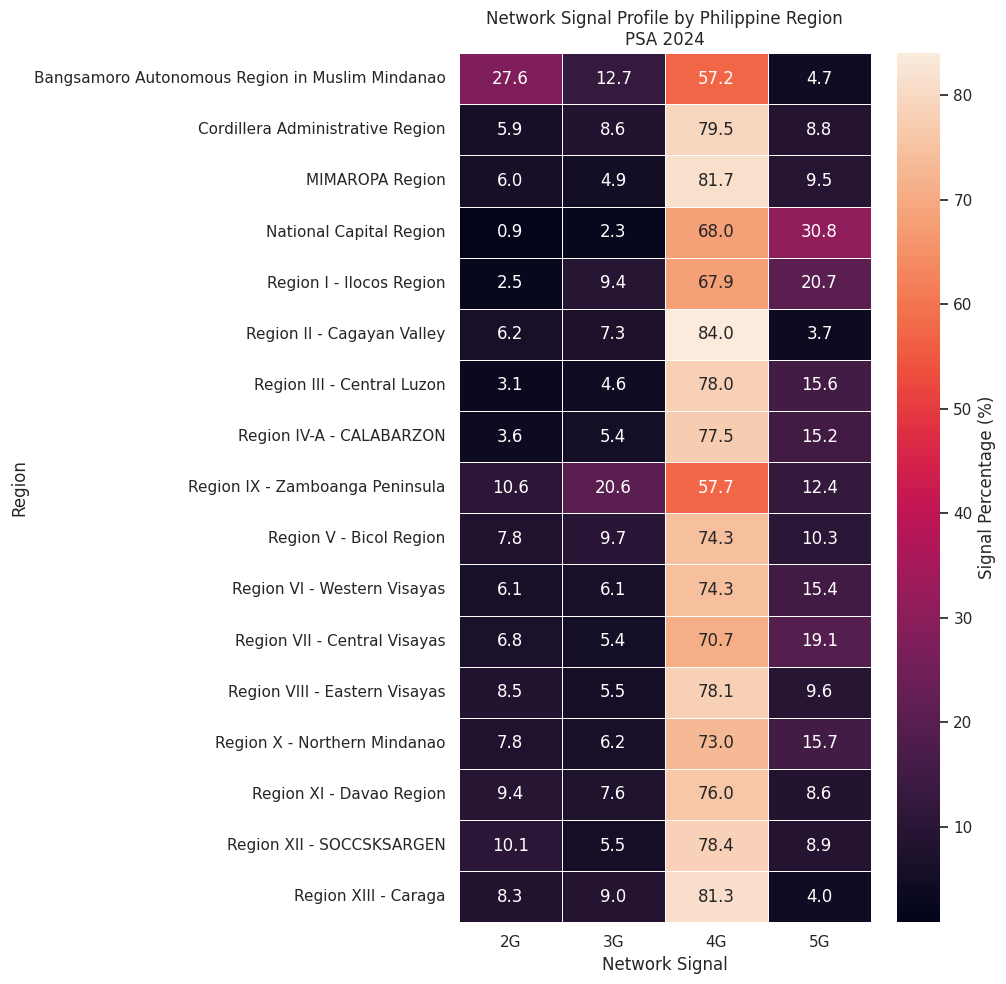

In [284]:
# @title
# ============================================================
# 39. BOXED REGIONAL NETWORK-SIGNAL HEATMAP
# ============================================================
# annot=True:
#   displays the actual percentage inside each box.
#
# linewidths:
#   creates visible boundaries between cells, giving the
#   visualization the boxed-table appearance.
#
# fmt=".1f":
#   formats each value to one decimal place.

plt.figure(figsize=(10, 10))

ax = sns.heatmap(
    signal_matrix,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Signal Percentage (%)"
    }
)

plt.title(
    "Network Signal Profile by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Network Signal")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [285]:
# @title
# ============================================================
# 40. COMBINE SIGNAL PROFILE WITH OVERALL INTERNET USE
# ============================================================
# Convert the signal matrix back into a normal dataframe and
# add the overall internet-use percentage for each region.

signal_internet = (
    signal_matrix
    .reset_index()
    .merge(
        regional_internet_use[
            ["Region", "Percentage"]
        ].rename(columns={
            "Percentage": "Overall_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(signal_internet)

,Region,2G,3G,4G,5G,Overall_Internet_Use
0,Bangsamoro Autonomous Region in Muslim Mindanao,27.6,12.7,57.2,4.7,40.5
1,Cordillera Administrative Region,5.9,8.6,79.5,8.8,71.5
2,MIMAROPA Region,6.0,4.9,81.7,9.5,63.3
3,National Capital Region,0.9,2.3,68.0,30.8,79.4
4,Region I - Ilocos Region,2.5,9.4,67.9,20.7,74.1
5,Region II - Cagayan Valley,6.2,7.3,84.0,3.7,74.6
6,Region III - Central Luzon,3.1,4.6,78.0,15.6,74.0
7,Region IV-A - CALABARZON,3.6,5.4,77.5,15.2,71.3
8,Region IX - Zamboanga Peninsula,10.6,20.6,57.7,12.4,50.1
9,Region V - Bicol Region,7.8,9.7,74.3,10.3,63.2


In [286]:
# @title
# ============================================================
# 41. VALIDATE SIGNAL + INTERNET COMBINATION
# ============================================================

print("SIGNAL + INTERNET VALIDATION")
print("-" * 60)

print(
    f"Rows: "
    f"{len(signal_internet)}"
)

print(
    f"Duplicate regions: "
    f"{signal_internet['Region'].duplicated().sum()}"
)

print(
    f"Missing values: "
    f"{signal_internet.isna().sum().sum()}"
)

if (
    len(signal_internet) == 17
    and signal_internet["Region"].duplicated().sum() == 0
    and signal_internet.isna().sum().sum() == 0
):
    print("Validation: PASS")
else:
    print("Validation: CHECK")

SIGNAL + INTERNET VALIDATION
------------------------------------------------------------
Rows: 17
Duplicate regions: 0
Missing values: 0
Validation: PASS


In [287]:
# @title
# ============================================================
# 42. CALCULATE NETWORK-SIGNAL CORRELATIONS
# ============================================================
# These correlations describe whether regional signal
# percentages move together with overall internet use.
#
# Positive:
#   higher signal percentage tends to occur with higher
#   overall internet use.
#
# Negative:
#   higher signal percentage tends to occur with lower
#   overall internet use.
#
# Correlation does NOT establish causation.

signal_correlations = (
    signal_internet[
        [
            "2G",
            "3G",
            "4G",
            "5G",
            "Overall_Internet_Use"
        ]
    ]
    .corr()["Overall_Internet_Use"]
    .drop("Overall_Internet_Use")
    .sort_values(
        ascending=False
    )
)

print("CORRELATION WITH OVERALL INTERNET USE")
print("-" * 60)

display(
    signal_correlations
    .rename("Pearson Correlation")
    .to_frame()
)

CORRELATION WITH OVERALL INTERNET USE
------------------------------------------------------------


,Pearson Correlation
4G,0.537670
5G,0.486097
3G,-0.625580
2G,-0.866247


In [288]:
# @title
# ============================================================
# 43. CORRELATION MATRIX
# ============================================================
# This is a diagnostic visualization.
#
# It summarizes the relationships among:
# 2G, 3G, 4G, 5G, and Overall Internet Use.

correlation_matrix = (
    signal_internet[
        [
            "2G",
            "3G",
            "4G",
            "5G",
            "Overall_Internet_Use"
        ]
    ]
    .corr()
)

display(correlation_matrix)

,2G,3G,4G,5G,Overall_Internet_Use
2G,1.000000,0.497745,-0.499516,-0.558950,-0.866247
3G,0.497745,1.000000,-0.617801,-0.347549,-0.625580
4G,-0.499516,-0.617801,1.000000,-0.306643,0.537670
5G,-0.558950,-0.347549,-0.306643,1.000000,0.486097
Overall_Internet_Use,-0.866247,-0.625580,0.537670,0.486097,1.000000


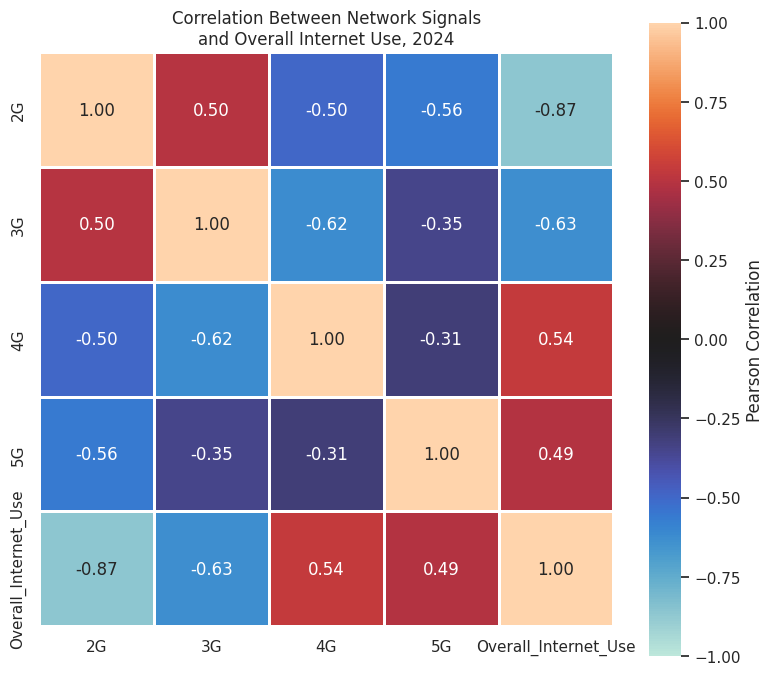

In [289]:
# @title
# ============================================================
# 44. BOXED CORRELATION HEATMAP
# ============================================================
# Values range from -1 to +1:
#
# +1 = strong positive relationship
#  0 = little linear relationship
# -1 = strong negative relationship

plt.figure(figsize=(8, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Correlation Between Network Signals\n"
    "and Overall Internet Use, 2024"
)

plt.tight_layout()
plt.show()

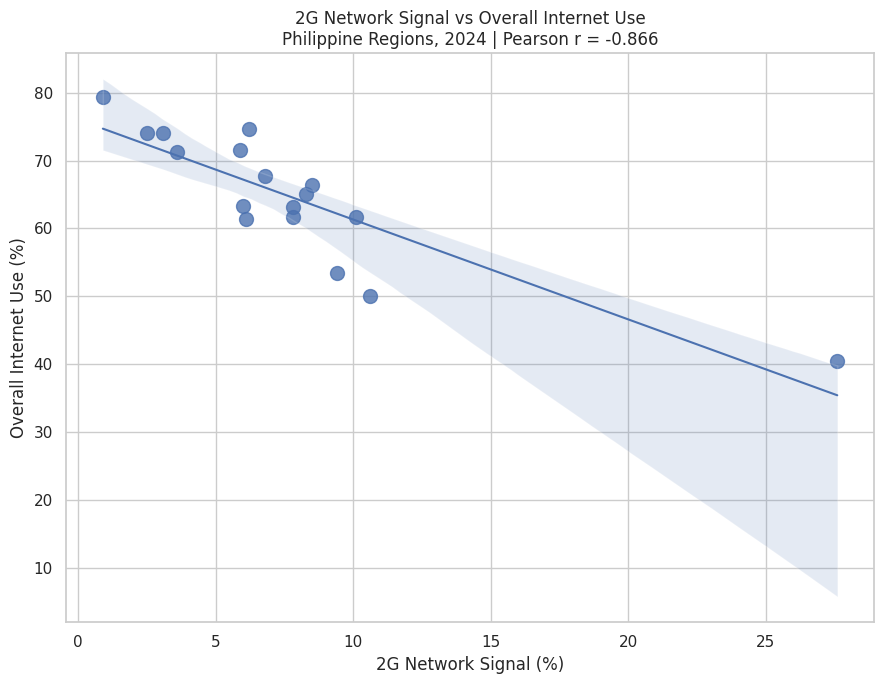

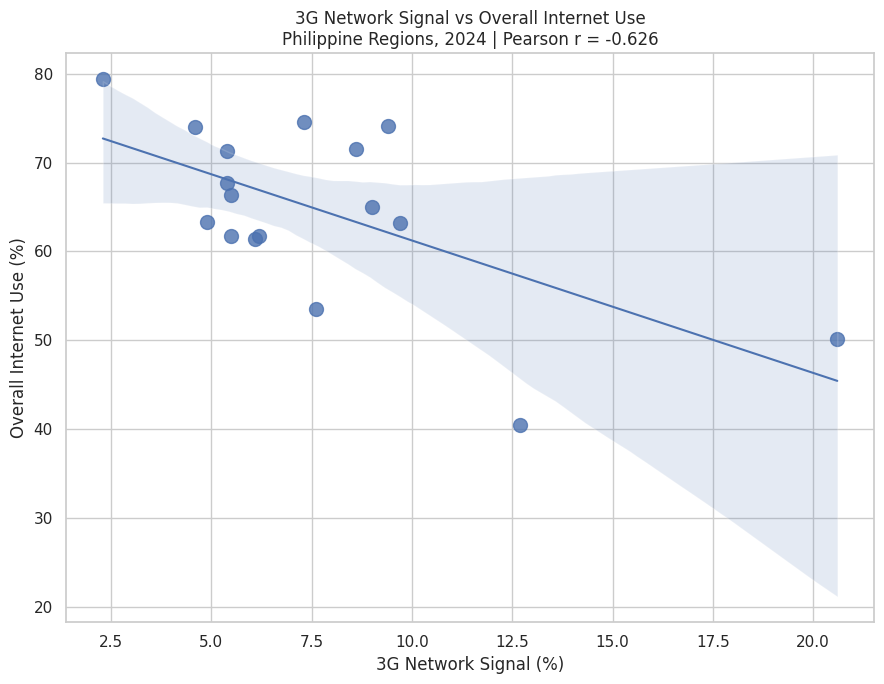

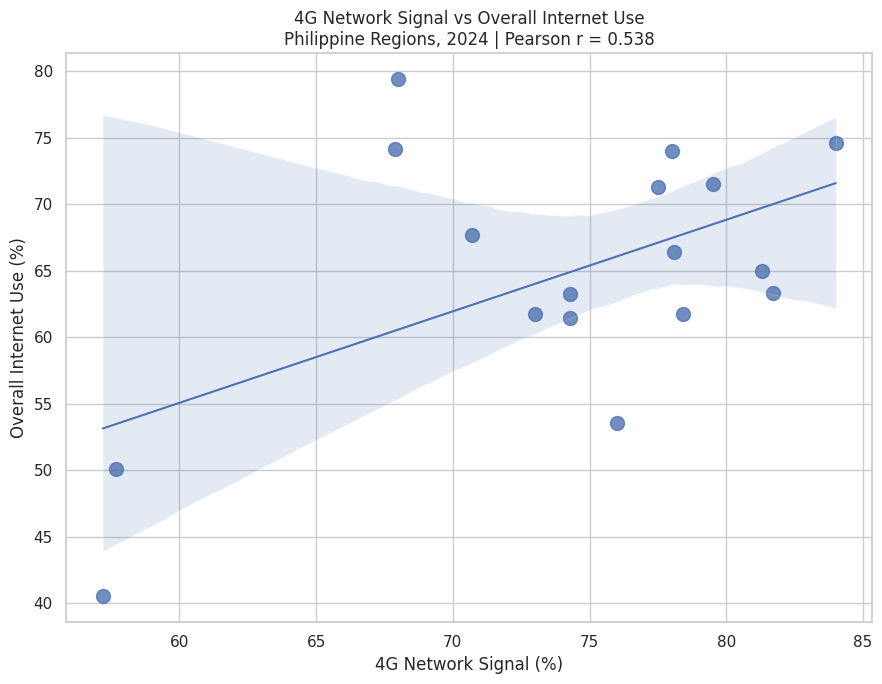

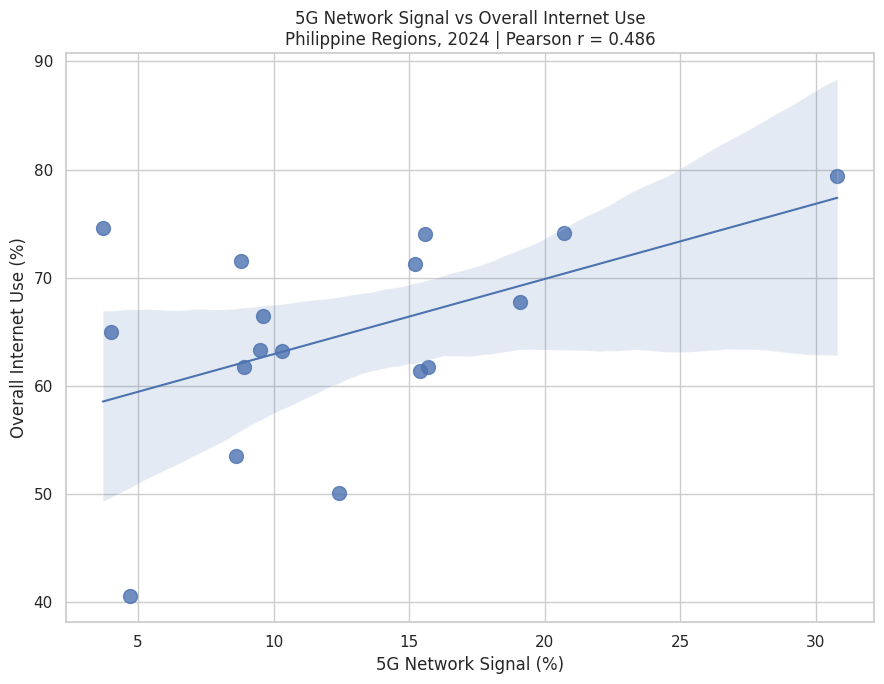

In [290]:
# @title
# ============================================================
# 46. SCATTER PLOTS WITH CORRELATION VALUES
# ============================================================

for signal in signal_categories:

    # Calculate correlation for the current signal.
    r = signal_internet[
        [signal, "Overall_Internet_Use"]
    ].corr().iloc[0, 1]

    plt.figure(figsize=(9, 7))

    sns.regplot(
        data=signal_internet,
        x=signal,
        y="Overall_Internet_Use",
        scatter_kws={
            "s": 100,
            "alpha": 0.8
        },
        line_kws={
            "linewidth": 1.5
        }
    )

    plt.title(
        f"{signal} Network Signal vs Overall Internet Use\n"
        f"Philippine Regions, 2024 | Pearson r = {r:.3f}"
    )

    plt.xlabel(
        f"{signal} Network Signal (%)"
    )

    plt.ylabel(
        "Overall Internet Use (%)"
    )

    plt.tight_layout()
    plt.show()

### Evidence

The regional network-signal matrix contains all **17 Philippine regions** and all four network-signal categories, with no missing values.

At the national level, the recorded network-signal percentages are:

- **2G:** 5.9%
- **3G:** 6.3%
- **4G:** 73.7%
- **5G:** 15.9%

The regional heatmap shows substantial differences in network-signal profiles.

Examples include:

- **NCR:** 0.9% 2G, 2.3% 3G, 68.0% 4G, and 30.8% 5G
- **BARMM:** 27.6% 2G, 12.7% 3G, 57.2% 4G, and 4.7% 5G
- **Zamboanga Peninsula:** 10.6% 2G, 20.6% 3G, 57.7% 4G, and 12.4% 5G
- **Cagayan Valley:** 6.2% 2G, 7.3% 3G, 84.0% 4G, and 3.7% 5G

The relationship between each network-signal percentage and overall internet use also differs:

- **2G:** r = **-0.866**
- **3G:** r = **-0.626**
- **4G:** r = **0.538**
- **5G:** r = **0.486**

Among the four signal categories, 2G has the strongest relationship with overall internet use in absolute terms, and the relationship is negative.

Regions with larger 2G percentages generally tend to report lower overall internet use.

By comparison, 4G and 5G show positive but more moderate regional relationships with overall internet use.

### Interpretation

The results show that Philippine regions do not share the same network-signal profile.

4G is the largest national signal category at 73.7%, but the regional heatmap shows that the mix of older and newer network technologies varies considerably.

The correlation analysis provides an additional insight.

Higher 2G percentages are strongly associated with lower overall internet use across regions, with a Pearson correlation of approximately **-0.866**.

The relationship is also negative for 3G, although weaker at approximately **-0.626**.

In contrast, both 4G and 5G have positive relationships with overall internet use:

- 4G: approximately **0.538**
- 5G: approximately **0.486**

This suggests that regions with a larger presence of older network-signal categories tend to also have lower overall internet use, while regions with greater percentages of newer network technologies generally tend to report higher internet use.

However, the relationship is not uniform.

For example, Cagayan Valley has the highest recorded 4G percentage at 84.0% while its 5G percentage is only 3.7%, yet its overall internet-use percentage remains relatively high at 74.6%.

This indicates that 5G percentage alone does not explain regional internet-use differences.

### Limitation

The network-signal categories may overlap and should not be interpreted as mutually exclusive components of a 100% total.

The correlations are based on only **17 regional observations** and describe regional associations in the 2024 PSA data.

They do not establish that a particular network technology causes higher or lower internet use.

The signal percentages also should not automatically be interpreted as direct measures of network quality, speed, reliability, or infrastructure coverage.

Other social, economic, geographic, and infrastructure conditions that are not included in these datasets may also contribute to the observed regional differences.

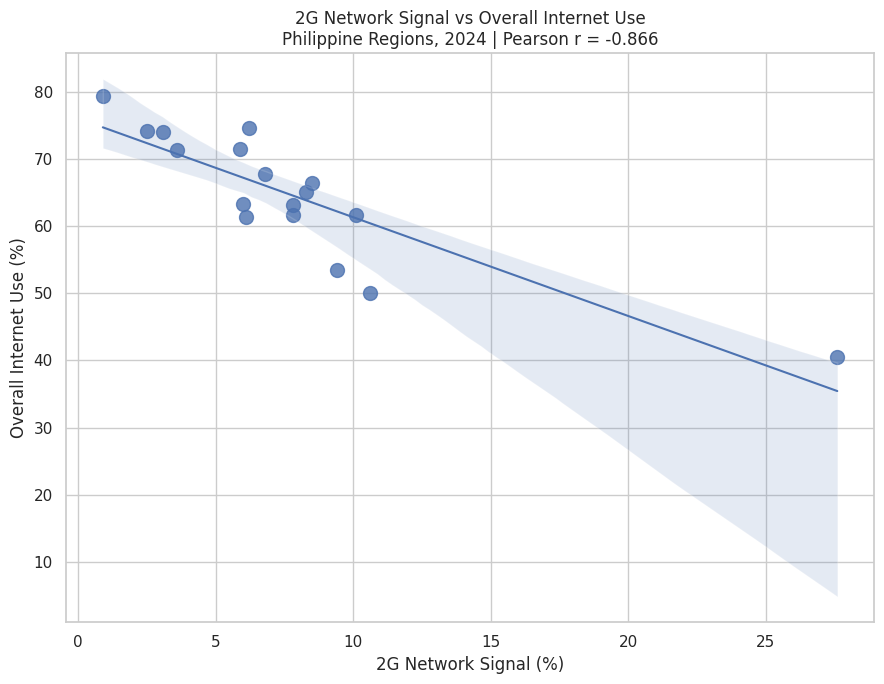

In [291]:
# @title
# ============================================================
# 47. FOCUSED SCATTER:
#     2G NETWORK SIGNAL VS OVERALL INTERNET USE
# ============================================================
# 2G produced the strongest absolute correlation with overall
# internet use among the four network-signal categories.
#
# The purpose of this chart is therefore to examine that
# relationship more closely.

signal_2g_correlation = (
    signal_internet[
        ["2G", "Overall_Internet_Use"]
    ]
    .corr()
    .iloc[0, 1]
)

plt.figure(figsize=(9, 7))

sns.regplot(
    data=signal_internet,
    x="2G",
    y="Overall_Internet_Use",
    scatter_kws={
        "s": 100,
        "alpha": 0.8
    },
    line_kws={
        "linewidth": 1.5
    }
)

plt.title(
    "2G Network Signal vs Overall Internet Use\n"
    f"Philippine Regions, 2024 | Pearson r = {signal_2g_correlation:.3f}"
)

plt.xlabel("2G Network Signal (%)")
plt.ylabel("Overall Internet Use (%)")

plt.tight_layout()
plt.show()

### Focused Relationship: 2G and Overall Internet Use

Among the four network-signal categories, 2G shows the strongest relationship with overall internet use.

The Pearson correlation is approximately **-0.866**, indicating a strong negative regional association.

Regions with higher 2G percentages generally tend to have lower overall internet-use percentages.

For example:

- **NCR:** 0.9% 2G and 79.4% overall internet use
- **BARMM:** 27.6% 2G and 40.5% overall internet use
- **Zamboanga Peninsula:** 10.6% 2G and 50.1% overall internet use

This pattern suggests that a greater regional presence of older network technology may be associated with lower levels of internet use.

However, this result should not be interpreted as evidence that 2G causes lower internet use. The relationship may also reflect broader differences in infrastructure, geography, accessibility, or other regional conditions not represented in the current datasets.

### Candidate Visualization Assessment

**Candidate visualization: Highlight Table / Boxed Heatmap**

The regional network-signal heatmap is a strong supporting candidate because it compares all four signal categories across all 17 regions in one view.

### Suggested Mapping

- **Rows:** Region
- **Columns:** Network Signal
- **Color:** Signal Percentage
- **Label:** Signal Percentage
- **Tooltip:** Region, Signal Type, Percentage

### Design Considerations

- use one sequential color scale for percentage intensity
- display percentages to one decimal place inside each cell
- keep visible borders between cells
- maintain the signal order 2G → 3G → 4G → 5G
- do not treat row totals as 100%
- consider sorting regions by overall internet use or by a selected signal
- use tooltips for supporting details

### Advantages

- compares four network technologies in one compact view
- makes regional differences easy to scan
- adds a different visual form from the map and scatter plots
- supports infrastructure-related interpretation

### Downsides

- more complex than a simple bar chart
- color comparison is less precise than direct position or length
- a general audience may need a short explanation
- too many extra annotations could make the matrix crowded

### Possible Dashboard Role

**Supporting Candidate**

### Current Assessment

**Strong Supporting Candidate**

The heatmap is worth carrying forward for group review, but it is not treated as a final Tableau selection yet.


# 9. Internet Activities by Region

## Analytical Questions

1. **What are the most common recorded internet activities nationally?**
2. **Which internet activities show the greatest differences across Philippine regions?**
3. **Which visualization approach communicates these patterns most clearly?**

## Purpose

The previous sections focused on internet reach, frequency of use, working-device availability, and network-signal conditions.

This section shifts the analysis from **whether and how often people use the internet** to **what they actually use it for**.

The Internet Activity dataset contains multiple possible activities for each user. The percentages are therefore interpreted independently and are **not treated as parts of a 100% total**.

Rather than selecting a chart in advance, this section tests different visualization approaches and compares their advantages and downsides.

The activity visualizations in this section are exploratory candidates only. The group will decide later which approach, if any, should be included in the final Tableau dashboard.


In [292]:
# @title
# ============================================================
# 48. VALIDATE INTERNET-ACTIVITY DATA
# ============================================================
# Expected structure:
#
# 22 activities × 18 geographic categories
# = 396 records
#
# Geographic categories:
# - PHILIPPINES
# - 17 individual regions

activity_categories = sorted(
    df_activity["Internet Activity"].unique()
)

activity_regions = sorted(
    df_activity["Region"].unique()
)

print("INTERNET-ACTIVITY DATA VALIDATION")
print("-" * 60)

print(f"Activities: {len(activity_categories)}")
print(f"Geographic categories: {len(activity_regions)}")
print(f"Total records: {len(df_activity)}")

print(
    f"Missing Number values: "
    f"{df_activity['Number'].isna().sum()}"
)

print(
    f"Missing Percentage values: "
    f"{df_activity['Percentage'].isna().sum()}"
)

duplicate_activity_records = (
    df_activity[
        ["Region", "Internet Activity"]
    ]
    .duplicated()
    .sum()
)

print(
    f"Duplicate Region + Activity records: "
    f"{duplicate_activity_records}"
)

if (
    len(activity_categories) == 22
    and len(activity_regions) == 18
    and len(df_activity) == 396
    and df_activity["Number"].isna().sum() == 0
    and df_activity["Percentage"].isna().sum() == 0
    and duplicate_activity_records == 0
):
    print("Activity dataset validation: PASS")
else:
    print("Activity dataset validation: CHECK")

INTERNET-ACTIVITY DATA VALIDATION
------------------------------------------------------------
Activities: 22
Geographic categories: 18
Total records: 396
Missing Number values: 0
Missing Percentage values: 0
Duplicate Region + Activity records: 0
Activity dataset validation: PASS


In [293]:
# @title
# ============================================================
# 49. PREPARE NATIONAL INTERNET-ACTIVITY RANKING
# ============================================================
# PHILIPPINES is used to describe the national activity profile.
#
# Multiple activities may apply to the same individual, so these
# percentages should NOT be added together as parts of one total.

national_activity = (
    df_activity.loc[
        df_activity["Region"] == "PHILIPPINES",
        ["Internet Activity", "Number", "Percentage"]
    ]
    .copy()
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking after sorting.
national_activity["Rank"] = (
    national_activity.index + 1
)

display(
    national_activity[
        [
            "Rank",
            "Internet Activity",
            "Number",
            "Percentage"
        ]
    ]
)

,Rank,Internet Activity,Number,Percentage
0,1,Internet Calls,57884800,63.3
1,2,Social Networking,53625010,58.7
2,3,Streaming Media,39083898,42.8
3,4,Email,26688320,29.2
4,5,Goods or Services,25482012,27.9
5,6,Games,21719720,23.8
6,7,Created Content,21067653,23.1
7,8,Software Downloads,17438093,19.1
8,9,Health Information,13172924,14.4
9,10,Government Information,12783072,14.0


In [294]:
# @title
# ============================================================
# 60. ACTIVITY VISUALIZATION PRIORITY SCORE
# ============================================================
# This score is ONLY a visualization-planning tool.
#
# It combines:
# - national activity prevalence
# - regional variation
#
# Both components are normalized to 0-1 before averaging.
#
# This cell also rebuilds activity_variation if the runtime
# was restarted or the earlier cell was not executed.

# ------------------------------------------------------------
# Rebuild prerequisites if needed
# ------------------------------------------------------------

if "national_activity" not in globals():

    national_activity = (
        df_activity.loc[
            df_activity["Region"] == "PHILIPPINES",
            ["Internet Activity", "Number", "Percentage"]
        ]
        .copy()
        .sort_values(
            "Percentage",
            ascending=False
        )
        .reset_index(drop=True)
    )

    national_activity["Rank"] = (
        national_activity.index + 1
    )


if "regional_activity" not in globals():

    regional_activity = (
        df_activity[
            df_activity["Region"] != "PHILIPPINES"
        ]
        .copy()
    )


if "activity_variation" not in globals():

    activity_variation = (
        regional_activity
        .groupby("Internet Activity")
        .agg(
            Regional_Mean=("Percentage", "mean"),
            Regional_Min=("Percentage", "min"),
            Regional_Max=("Percentage", "max"),
            Regional_SD=("Percentage", "std")
        )
        .reset_index()
    )

    activity_variation["Regional_Range"] = (
        activity_variation["Regional_Max"]
        - activity_variation["Regional_Min"]
    )

    activity_variation = (
        activity_variation
        .merge(
            national_activity[
                [
                    "Internet Activity",
                    "Percentage"
                ]
            ].rename(
                columns={
                    "Percentage": "National_Percentage"
                }
            ),
            on="Internet Activity",
            how="left"
        )
    )


# ------------------------------------------------------------
# Create visualization priority score
# ------------------------------------------------------------

activity_priority = activity_variation.copy()

national_min = (
    activity_priority["National_Percentage"].min()
)

national_max = (
    activity_priority["National_Percentage"].max()
)

range_min = (
    activity_priority["Regional_Range"].min()
)

range_max = (
    activity_priority["Regional_Range"].max()
)

activity_priority["National_Score"] = (
    (
        activity_priority["National_Percentage"]
        - national_min
    )
    /
    (
        national_max
        - national_min
    )
)

activity_priority["Variation_Score"] = (
    (
        activity_priority["Regional_Range"]
        - range_min
    )
    /
    (
        range_max
        - range_min
    )
)

# Equal weighting:
# 50% national prevalence
# 50% regional variation
activity_priority["Visualization_Priority"] = (
    (
        activity_priority["National_Score"]
        + activity_priority["Variation_Score"]
    )
    / 2
)

activity_priority = (
    activity_priority
    .sort_values(
        "Visualization_Priority",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    activity_priority[
        [
            "Internet Activity",
            "National_Percentage",
            "Regional_Range",
            "Visualization_Priority"
        ]
    ]
)

,Internet Activity,National_Percentage,Regional_Range,Visualization_Priority
0,Internet Calls,63.3,39.9,1.000000
1,Social Networking,58.7,29.3,0.812140
2,Email,29.2,37.5,0.683349
3,Streaming Media,42.8,29.1,0.677474
4,Goods or Services,27.9,29.6,0.560987
5,Games,23.8,23.0,0.433770
6,Health Information,14.4,25.4,0.389725
7,Web Television,13.8,23.6,0.359326
8,Software Downloads,19.1,19.6,0.346776
9,Government Information,14.0,17.8,0.279064


### 9.1 Activity Priority Score Limitation

The visualization-priority score is a **planning tool created only for this exploratory notebook**.

It is not a PSA indicator and should not be presented as an official statistical measure.

The score gives equal weight to:

- national activity prevalence
- highest-to-lowest regional variation

Its only purpose is to help identify activities that may be useful when comparing visualization options.


## 9.2 Comparing Three Visualization Candidates

The Internet Activity dataset can be presented in different ways depending on what the audience needs to understand.

Three exploratory visualization techniques will be tested:

1. **Word Cloud**
   - emphasizes which activities are more prominent nationally

2. **Sorted Horizontal Bar Chart**
   - emphasizes national ranking and precise percentage comparison

3. **Regional Boxed Heatmap**
   - emphasizes how selected activities differ across regions

These are not final dashboard selections. The purpose is to compare their strengths and limitations before the group chooses a visualization for Milestone 2.


### Candidate 1: Word Cloud

A word cloud uses text size to represent the national percentage recorded for each internet activity.

Activities with higher percentages appear larger, while activities with lower percentages appear smaller.

This candidate is tested because it provides a quick visual impression of which activities are most prominent nationally.


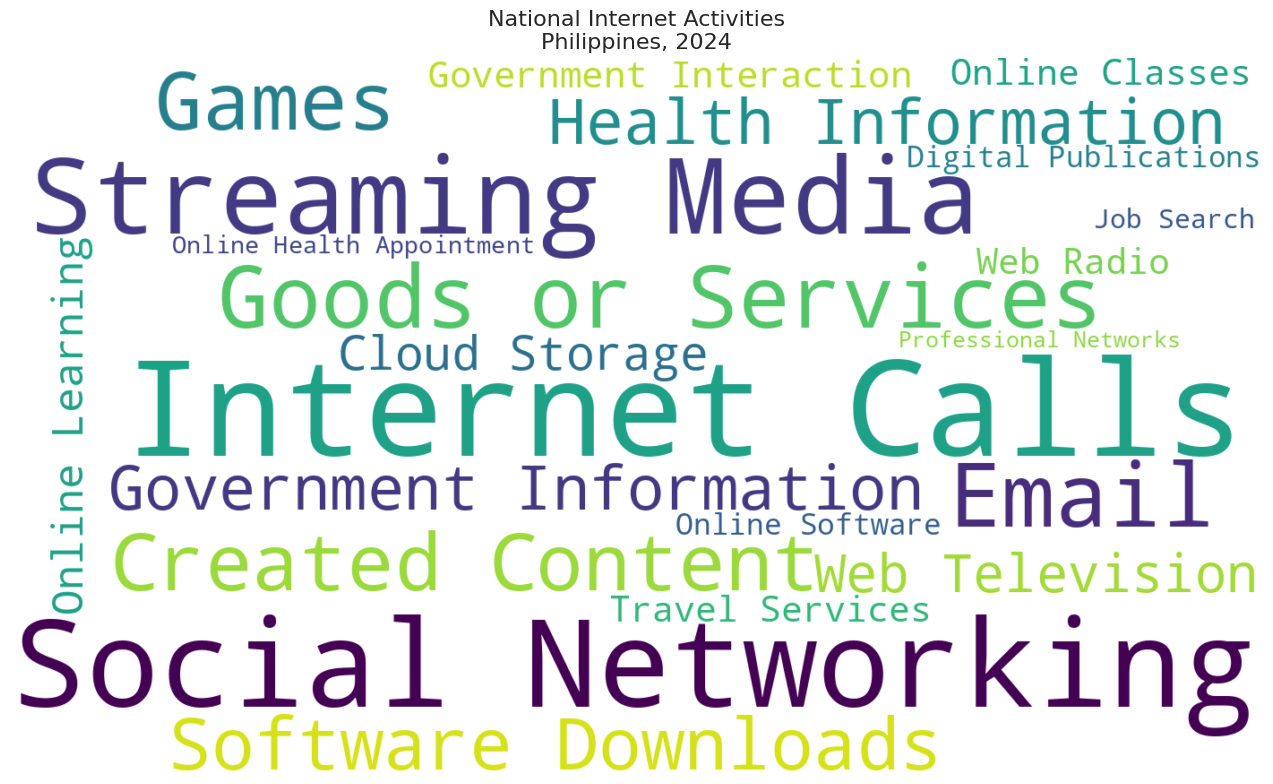

In [295]:
# ============================================================
# CANDIDATE 1: NATIONAL INTERNET-ACTIVITY WORD CLOUD
# ============================================================
# Font size represents the national percentage of each activity.
# This is exploratory and is not intended for precise comparison.

!pip -q install wordcloud

from wordcloud import WordCloud

activity_frequencies = dict(
    zip(
        national_activity["Internet Activity"],
        national_activity["Percentage"]
    )
)

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    prefer_horizontal=0.9,
    collocations=False
).generate_from_frequencies(
    activity_frequencies
)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("National Internet Activities\nPhilippines, 2024", fontsize=16)
plt.tight_layout()
plt.show()


#### Candidate 1 Assessment

**Advantages**

- quickly emphasizes the most common activities
- visually engaging and easy to scan
- compact way to display all 22 activities
- useful for giving a quick general impression

**Downsides**

- exact percentage differences are difficult to judge
- similar values may appear visually almost identical
- ranking is less clear than in a sorted chart
- does not show regional differences
- text size is less precise than bar length or position for quantitative comparison

**Current Assessment:** **Exploratory Candidate**

The word cloud may work as a supplementary visual overview, but it is weaker when the audience needs precise comparisons.


### Candidate 2: Sorted Horizontal Bar Chart

The horizontal bar chart uses bar length to compare the national percentage of each internet activity.

The activities are sorted so ranking and magnitude can be compared directly using the same national percentages shown in the word cloud.


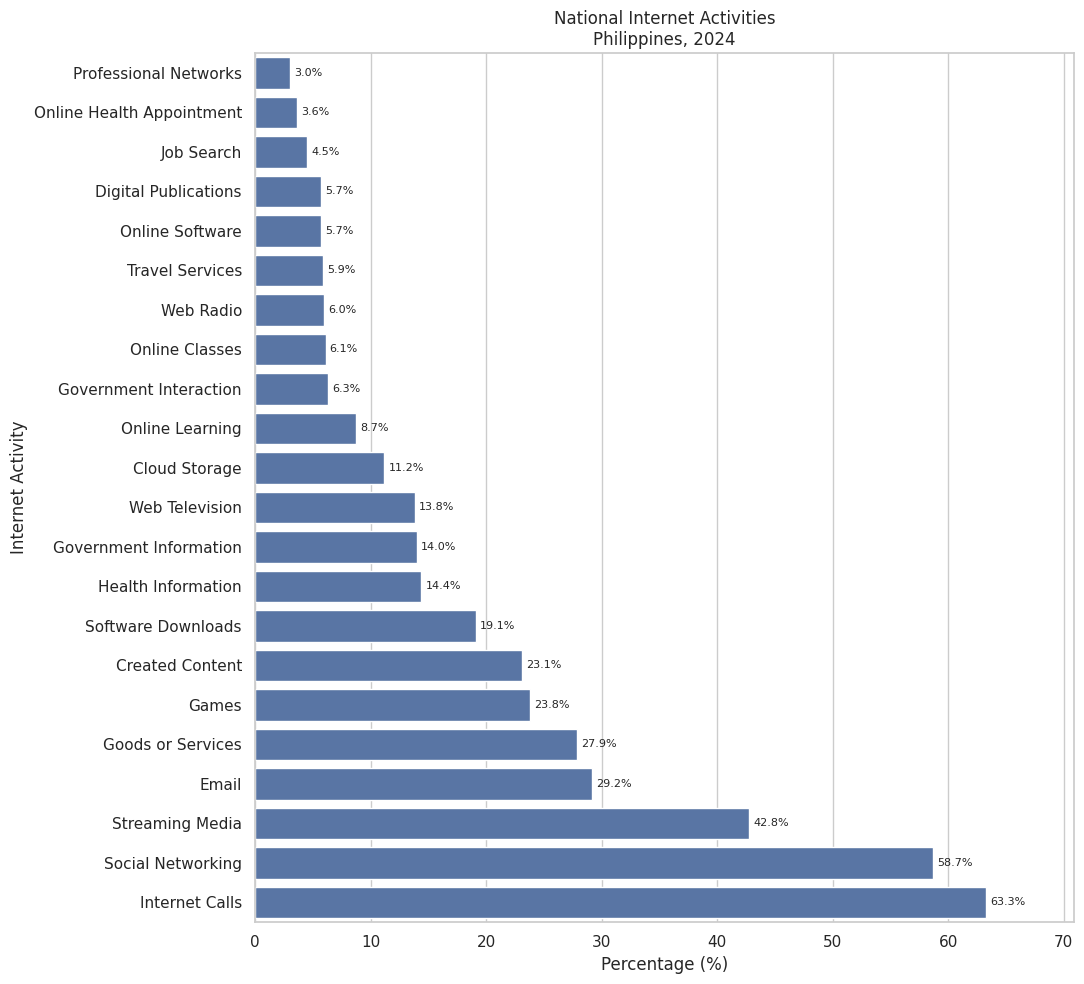

In [296]:
# @title
# ============================================================
# CANDIDATE 2: SORTED NATIONAL INTERNET-ACTIVITY BAR CHART
# ============================================================
# Same data as the word cloud, allowing a fair visual comparison.

activity_bar = (
    national_activity
    .sort_values("Percentage", ascending=True)
    .copy()
)

plt.figure(figsize=(11, 10))

ax = sns.barplot(
    data=activity_bar,
    y="Internet Activity",
    x="Percentage"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.title("National Internet Activities\nPhilippines, 2024")
plt.xlabel("Percentage (%)")
plt.ylabel("Internet Activity")
plt.xlim(0, activity_bar["Percentage"].max() * 1.12)
plt.tight_layout()
plt.show()


#### Candidate 2 Assessment

**Advantages**

- clearly shows the ranking of activities
- percentage differences are easier to compare
- exact values can be displayed directly
- long activity names work well in a horizontal layout
- provides stronger quantitative accuracy than the word cloud

**Downsides**

- takes more vertical space because there are 22 activities
- less compact than the word cloud
- may appear dense inside a small dashboard
- shows the national profile but not regional variation

**Current Assessment:** **Strong Exploratory Candidate**

The horizontal bar chart is stronger for precise comparison, but its space requirement needs to be considered during dashboard design.


### Candidate 3: Regional Boxed Heatmap

The heatmap focuses on regional differences rather than only national prevalence.

To keep the exploratory view readable, it uses the **eight activities with the highest visualization-priority scores**.

The priority score is used only to create a manageable shortlist. It does not determine the final dashboard content.


ACTIVITIES INCLUDED IN THE HEATMAP
------------------------------------------------------------
- Internet Calls
- Social Networking
- Email
- Streaming Media
- Goods or Services
- Games
- Health Information
- Web Television

HEATMAP VALIDATION
------------------------------------------------------------
Regions: 17
Activities: 8
Missing values: 0


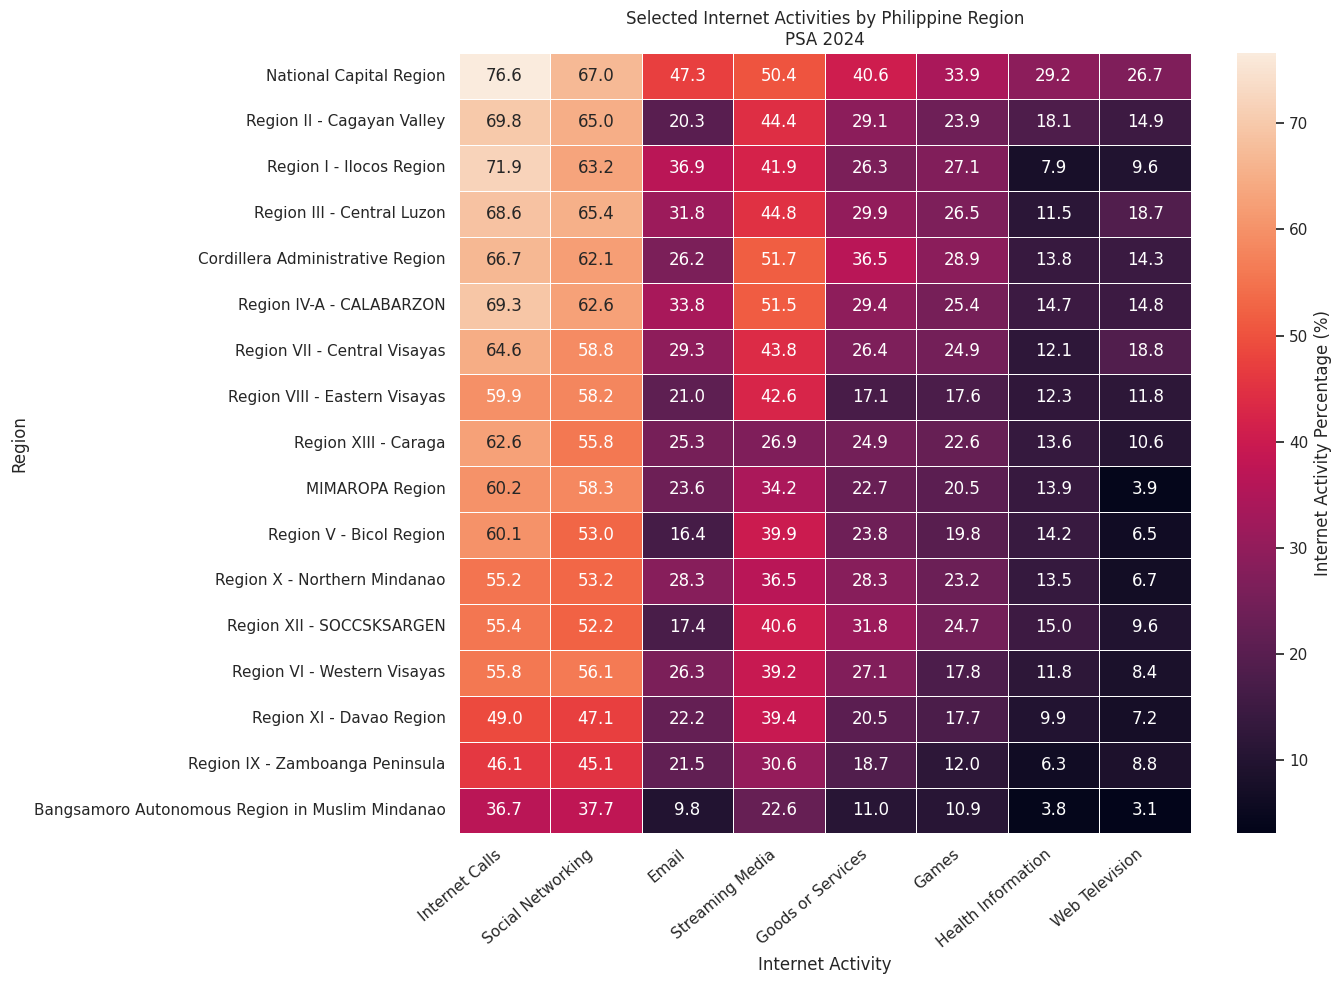

In [297]:
# @title
# ============================================================
# CANDIDATE 3: REGIONAL INTERNET-ACTIVITY HEATMAP
# ============================================================

top_8_activity_candidates = (
    activity_priority
    .head(8)["Internet Activity"]
    .tolist()
)

print("ACTIVITIES INCLUDED IN THE HEATMAP")
print("-" * 60)

for activity in top_8_activity_candidates:
    print(f"- {activity}")

activity_heatmap_top8 = (
    regional_activity[
        regional_activity["Internet Activity"]
        .isin(top_8_activity_candidates)
    ]
    .pivot(
        index="Region",
        columns="Internet Activity",
        values="Percentage"
    )
)

# Preserve exploratory priority order.
activity_heatmap_top8 = activity_heatmap_top8[
    top_8_activity_candidates
]

# Sort regions by overall internet-use percentage.
region_order = (
    regional_internet_use
    .sort_values("Percentage", ascending=False)["Region"]
    .tolist()
)

activity_heatmap_top8 = activity_heatmap_top8.reindex(region_order)

print()
print("HEATMAP VALIDATION")
print("-" * 60)
print(f"Regions: {activity_heatmap_top8.shape[0]}")
print(f"Activities: {activity_heatmap_top8.shape[1]}")
print(f"Missing values: {activity_heatmap_top8.isna().sum().sum()}")

plt.figure(figsize=(14, 10))

sns.heatmap(
    activity_heatmap_top8,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Internet Activity Percentage (%)"}
)

plt.title("Selected Internet Activities by Philippine Region\nPSA 2024")
plt.xlabel("Internet Activity")
plt.ylabel("Region")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


#### Candidate 3 Assessment

**Advantages**

- shows activity type and regional differences at the same time
- allows several activities and all 17 regions to be compared in one view
- color makes unusual regional patterns easier to notice
- exact percentages can still be displayed inside the cells
- aligns well with the project's regional digital-connectivity focus

**Downsides**

- more visually complex than the word cloud or bar chart
- requires more explanation for general audiences
- showing too many activities would reduce readability
- exact comparisons across distant cells can be difficult
- activity selection must be justified because all 22 activities cannot be shown comfortably

**Current Assessment:** **Strong Supporting Candidate**

The heatmap provides the most regional context of the three candidates, but it also requires the most careful design.


## 9.3 Visualization Candidate Comparison

| Visualization | Best For | Main Advantage | Main Downside | Current Assessment |
|---|---|---|---|---|
| **Word Cloud** | Quick overview of nationally prominent activities | Visually engaging and compact | Poor for exact quantitative comparison | Exploratory Candidate |
| **Horizontal Bar Chart** | Ranking national activity percentages | Clear ranking and precise comparison | Uses substantial vertical space and does not show regional variation | Strong Exploratory Candidate |
| **Regional Heatmap** | Comparing activity patterns across regions | Shows several activities and regional differences together | More complex and requires activity selection | Strong Supporting Candidate |

### Preliminary Comparison

No final Internet Activity visualization is selected at this stage.

The three candidates emphasize different aspects of the same dataset:

- the **word cloud** emphasizes visual prominence
- the **bar chart** emphasizes national ranking and precise comparison
- the **heatmap** emphasizes regional differences

If the dashboard needs a simple national overview, the horizontal bar chart may be the stronger option.

If the dashboard needs to emphasize regional differences in how people use the internet, the heatmap may provide more analytical value.

The word cloud may still be useful as a supplementary visual, but it provides less quantitative precision than the other two approaches.

The final choice should be made through group review together with the other dashboard candidates.


# 10. Age Composition of Internet Users

## Analytical Questions

1. **Which age groups make up the largest share of internet users nationally?**
2. **How does the age composition of internet users differ across Philippine regions?**
3. **Which visualization approach communicates the age pattern more clearly?**

## Purpose

The project includes demographic patterns as part of the overall digital-connectivity story.

This section examines the **age composition of recorded internet users** using the cleaned Age Group dataset.

The analysis does **not** measure internet penetration within each age group because the dataset does not provide the total population denominator for every age group.

Instead, the percentages describe how the recorded internet-user population is distributed across age groups.


### 10.1 Prepare and Validate the Age-Group Composition

The `Both Sexes` category represents the overall regional internet-use total and is excluded from the age-composition breakdown.

The `Not Reported` category is retained in validation because it exists in the source data. It may be excluded from the main visualization if its contribution is negligible and would add unnecessary clutter.


In [298]:
# @title
# ============================================================
# PREPARE AGE-GROUP COMPOSITION
# ============================================================

age_order = [
    "Age 10-14",
    "Age 15-24",
    "Age 25-34",
    "Age 35-44",
    "Age 45-54",
    "Age 55-64",
    "Age 65-74",
    "Age 75+",
    "Not Reported"
]

# National age composition.
national_age = (
    df_age[
        (df_age["Region"] == "PHILIPPINES") &
        (df_age["Age Group"].isin(age_order))
    ]
    [["Age Group", "Number", "Percentage"]]
    .copy()
)

national_age["Age Group"] = pd.Categorical(
    national_age["Age Group"],
    categories=age_order,
    ordered=True
)

national_age = (
    national_age
    .sort_values("Age Group")
    .reset_index(drop=True)
)

# Regional age composition.
regional_age = (
    df_age[
        (df_age["Region"] != "PHILIPPINES") &
        (df_age["Age Group"].isin(age_order))
    ]
    .copy()
)

# Validate that the age percentages approximately sum to 100%.
age_sum_check = (
    df_age[
        df_age["Age Group"].isin(age_order)
    ]
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Age_Percentage_Sum")
)

print("AGE-COMPOSITION VALIDATION")
print("-" * 60)
print(f"National age categories: {len(national_age)}")
print(f"Regional age records: {len(regional_age)}")
print(
    f"Minimum age-percentage sum: "
    f"{age_sum_check['Age_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum age-percentage sum: "
    f"{age_sum_check['Age_Percentage_Sum'].max():.1f}%"
)

display(national_age)


AGE-COMPOSITION VALIDATION
------------------------------------------------------------
National age categories: 9
Regional age records: 153
Minimum age-percentage sum: 99.8%
Maximum age-percentage sum: 100.1%


,Age Group,Number,Percentage
0,Age 10-14,6676343,10.9
1,Age 15-24,16736847,27.2
2,Age 25-34,14481475,23.6
3,Age 35-44,10540369,17.1
4,Age 45-54,6938125,11.3
5,Age 55-64,3981581,6.5
6,Age 65-74,1698518,2.8
7,Age 75+,411349,0.7
8,Not Reported,2502,0.0


### Candidate 1: National Age-Profile Bar Chart

A bar chart is tested because age groups have a natural order and bar length makes the relative share of each age group easy to compare.


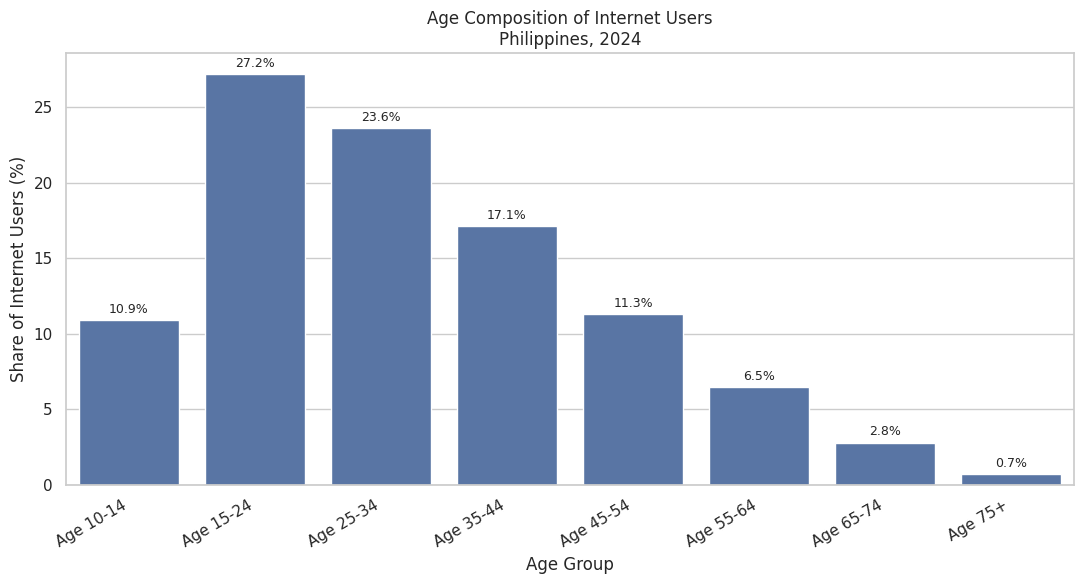

In [299]:
# @title
# ============================================================
# AGE CANDIDATE 1:
# NATIONAL AGE-PROFILE BAR CHART
# ============================================================

age_chart = national_age[
    national_age["Age Group"] != "Not Reported"
].copy()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=age_chart,
    x="Age Group",
    y="Percentage",
    order=[
        "Age 10-14",
        "Age 15-24",
        "Age 25-34",
        "Age 35-44",
        "Age 45-54",
        "Age 55-64",
        "Age 65-74",
        "Age 75+"
    ]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Age Composition of Internet Users\n"
    "Philippines, 2024"
)

plt.xlabel("Age Group")
plt.ylabel("Share of Internet Users (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


#### Candidate 1 Assessment

**Advantages**

- preserves the natural age progression
- easy to identify the largest and smallest age groups
- exact percentages can be labeled directly
- relatively easy for a general audience to understand

**Downsides**

- shows only the national age profile
- does not reveal how age composition differs by region
- should not be interpreted as internet penetration within each age group

**Current Assessment:** **Strong Exploratory Candidate**


### Candidate 2: Regional Age-Group Heatmap

A heatmap is tested to compare age composition across all 17 regions while preserving the ordered age groups.


AGE HEATMAP VALIDATION
------------------------------------------------------------
Regions: 17
Age groups: 8
Missing values: 0


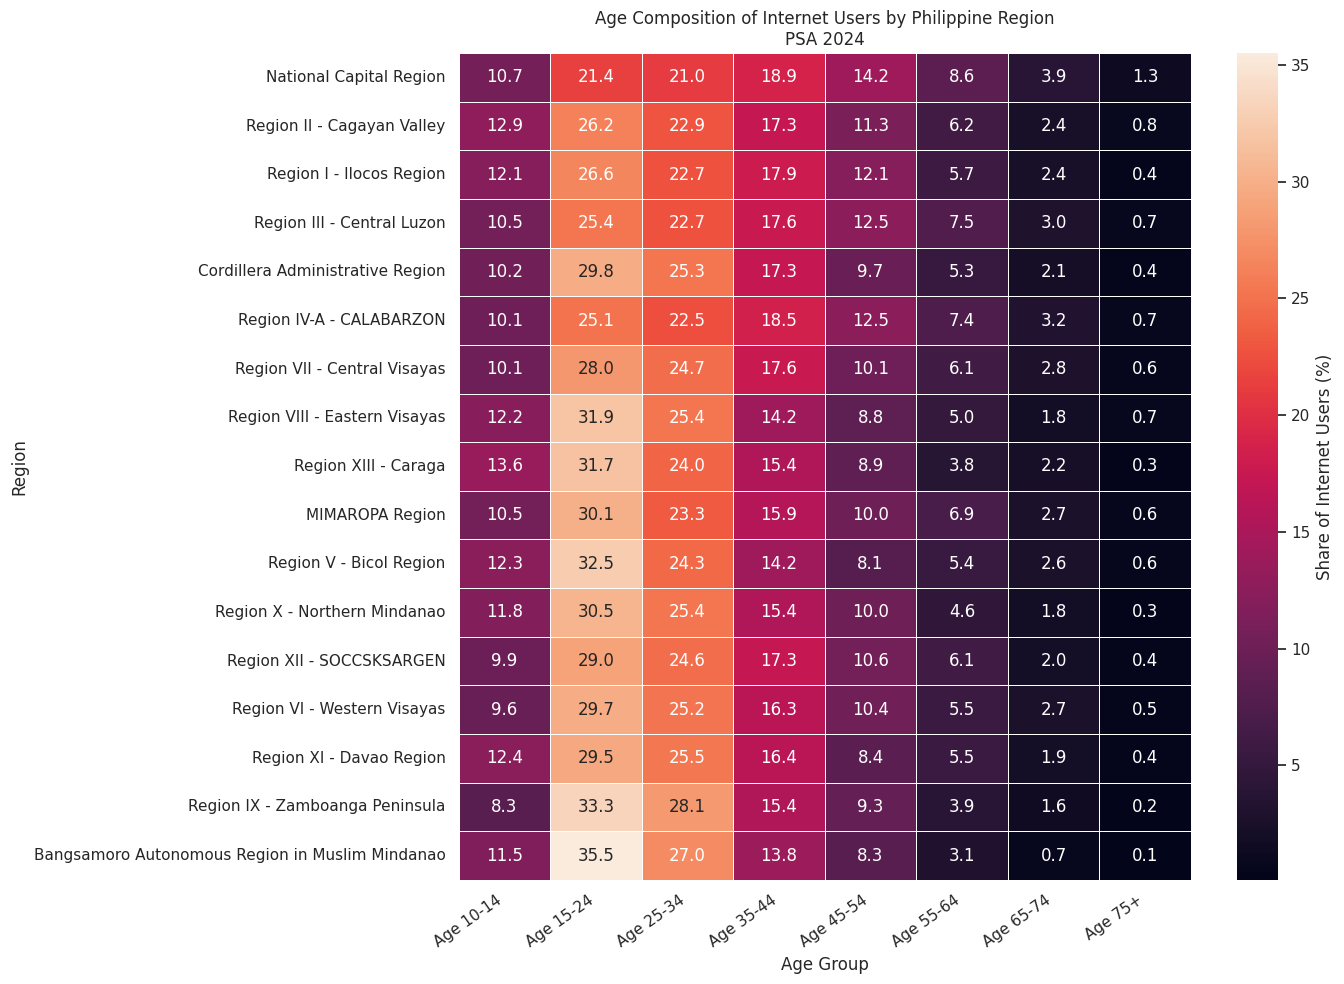

In [300]:
# @title
# ============================================================
# AGE CANDIDATE 2:
# REGIONAL AGE-GROUP HEATMAP
# ============================================================

age_heatmap_order = [
    "Age 10-14",
    "Age 15-24",
    "Age 25-34",
    "Age 35-44",
    "Age 45-54",
    "Age 55-64",
    "Age 65-74",
    "Age 75+"
]

age_heatmap = (
    regional_age[
        regional_age["Age Group"].isin(age_heatmap_order)
    ]
    .pivot(
        index="Region",
        columns="Age Group",
        values="Percentage"
    )
)

age_heatmap = age_heatmap[age_heatmap_order]

# Reuse the regional order from the overall internet-use analysis.
region_order = (
    regional_internet_use
    .sort_values("Percentage", ascending=False)["Region"]
    .tolist()
)

age_heatmap = age_heatmap.reindex(region_order)

print("AGE HEATMAP VALIDATION")
print("-" * 60)
print(f"Regions: {age_heatmap.shape[0]}")
print(f"Age groups: {age_heatmap.shape[1]}")
print(f"Missing values: {age_heatmap.isna().sum().sum()}")

plt.figure(figsize=(14, 10))

sns.heatmap(
    age_heatmap,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Share of Internet Users (%)"
    }
)

plt.title(
    "Age Composition of Internet Users by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Age Group")
plt.ylabel("Region")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


#### Candidate 2 Assessment

**Advantages**

- shows regional and demographic patterns in one view
- preserves the age-group structure across all regions
- exact values can be displayed inside cells
- useful for identifying regions with different age profiles

**Downsides**

- more complex than the national bar chart
- requires more dashboard space
- exact comparison across distant cells can be difficult
- still describes composition of internet users, not age-specific penetration

**Current Assessment:** **Strong Supporting Candidate**


### 10.2 Age Visualization Comparison

The national bar chart is stronger for a simple demographic overview.

The regional heatmap is stronger if the dashboard needs to show how the age composition of internet users differs across regions.

No final age visualization is selected at this stage.


# 11. Full Internet-Use Frequency Profile

## Analytical Questions

1. **How is internet-use frequency distributed across Daily, Weekly, Monthly, and Not Regular categories?**
2. **How does the full frequency profile differ across regions?**
3. **Does the complete frequency distribution communicate more than the Daily-use measure alone?**

## Purpose

Earlier analysis focused mainly on Daily internet use because it provided a clear measure of usage intensity.

This section expands the view to the complete frequency distribution.

The four frequency categories are treated as a composition of internet users and should total approximately 100%, allowing a full regional profile to be compared.


In [301]:
# @title
# ============================================================
# PREPARE AND VALIDATE FULL FREQUENCY PROFILE
# ============================================================

frequency_order = [
    "Daily",
    "Weekly",
    "Monthly",
    "Not Regular"
]

regional_frequency_profile = (
    df_frequency[
        (df_frequency["Region"] != "PHILIPPINES") &
        (df_frequency["Frequency"].isin(frequency_order))
    ]
    .copy()
)

national_frequency_profile = (
    df_frequency[
        (df_frequency["Region"] == "PHILIPPINES") &
        (df_frequency["Frequency"].isin(frequency_order))
    ]
    .copy()
)

frequency_sum_check = (
    df_frequency[
        df_frequency["Frequency"].isin(frequency_order)
    ]
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Frequency_Percentage_Sum")
)

print("FREQUENCY-COMPOSITION VALIDATION")
print("-" * 60)
print(
    f"Minimum composition sum: "
    f"{frequency_sum_check['Frequency_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum composition sum: "
    f"{frequency_sum_check['Frequency_Percentage_Sum'].max():.1f}%"
)

display(
    national_frequency_profile[
        ["Frequency", "Number", "Percentage"]
    ]
)


FREQUENCY-COMPOSITION VALIDATION
------------------------------------------------------------
Minimum composition sum: 99.9%
Maximum composition sum: 100.1%


,Frequency,Number,Percentage
1,Monthly,608690,1.0
3,Weekly,10056764,16.4
32,Daily,47253389,76.9
65,Not Regular,3548266,5.8


### Candidate 1: 100% Stacked Horizontal Bar Chart

A stacked horizontal bar is tested because the four frequency categories form an approximate 100% composition.

This chart emphasizes how the distribution of usage intensity differs across regions.


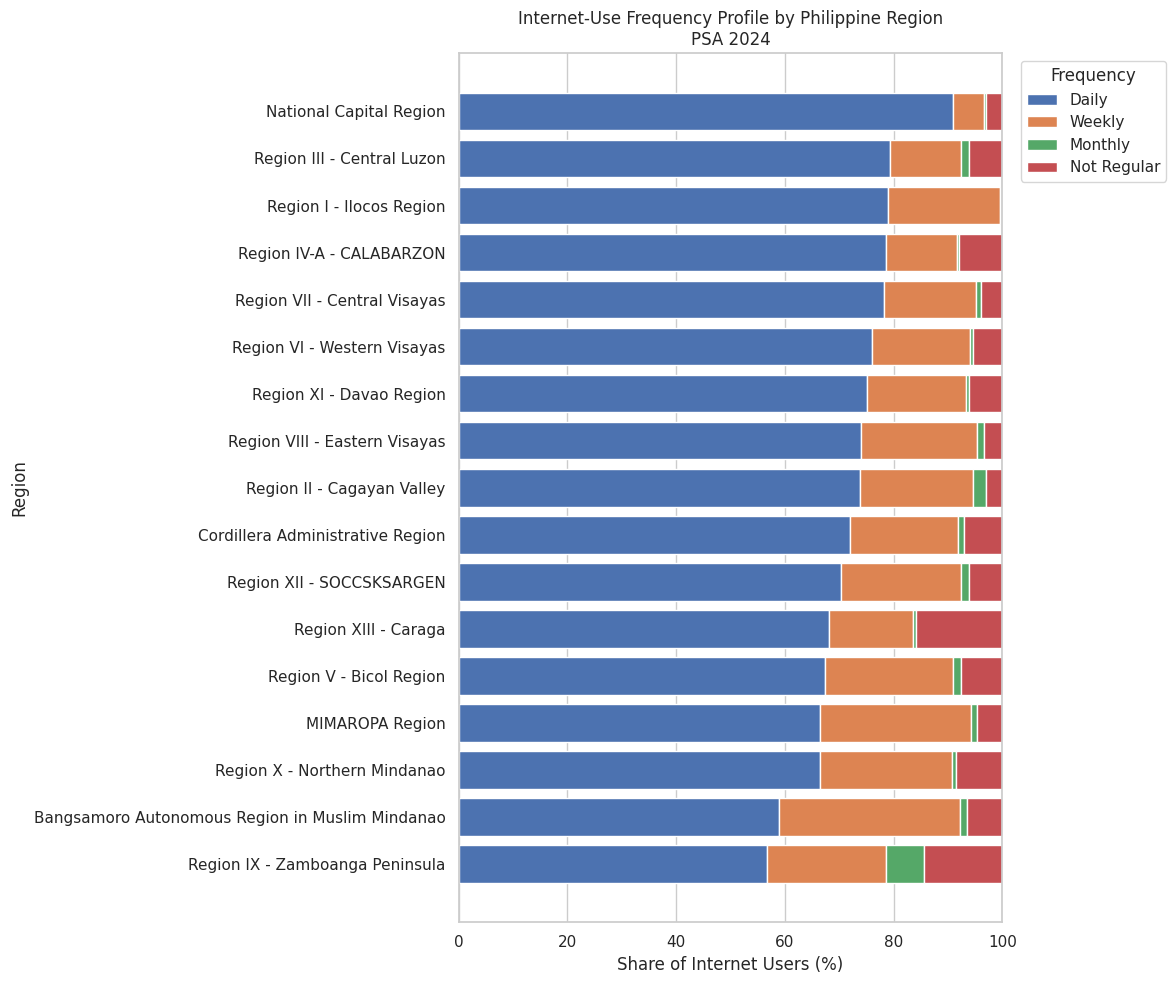

In [302]:
# @title
# ============================================================
# FREQUENCY CANDIDATE 1:
# 100% STACKED HORIZONTAL BAR CHART
# ============================================================
# Matplotlib is used here because stacked bars are not directly
# supported by Seaborn's standard barplot function.

frequency_matrix = (
    regional_frequency_profile
    .pivot(
        index="Region",
        columns="Frequency",
        values="Percentage"
    )
    [frequency_order]
)

# Sort regions by Daily share from highest to lowest.
frequency_matrix = (
    frequency_matrix
    .sort_values("Daily", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 10))

left = np.zeros(len(frequency_matrix))

for category in frequency_order:
    values = frequency_matrix[category].values

    ax.barh(
        frequency_matrix.index,
        values,
        left=left,
        label=category
    )

    left += values

ax.set_xlim(0, 100)

ax.set_title(
    "Internet-Use Frequency Profile by Philippine Region\n"
    "PSA 2024"
)

ax.set_xlabel("Share of Internet Users (%)")
ax.set_ylabel("Region")

ax.legend(
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


#### Candidate 1 Assessment

**Advantages**

- shows the complete frequency composition for every region
- makes Daily, Weekly, Monthly, and Not Regular use visible together
- useful for understanding the balance of frequent and less-frequent use
- provides more context than the Daily-only ranking

**Downsides**

- smaller categories can be difficult to compare precisely
- exact percentages require labels or tooltips
- 17 stacked bars can make a dashboard feel dense
- regional ranking for one specific category is less obvious than in a normal bar chart

**Current Assessment:** **Strong Exploratory Candidate**


### Candidate 2: Regional Frequency Heatmap

A heatmap is tested as an alternative because it makes exact regional differences within each frequency category easier to scan.


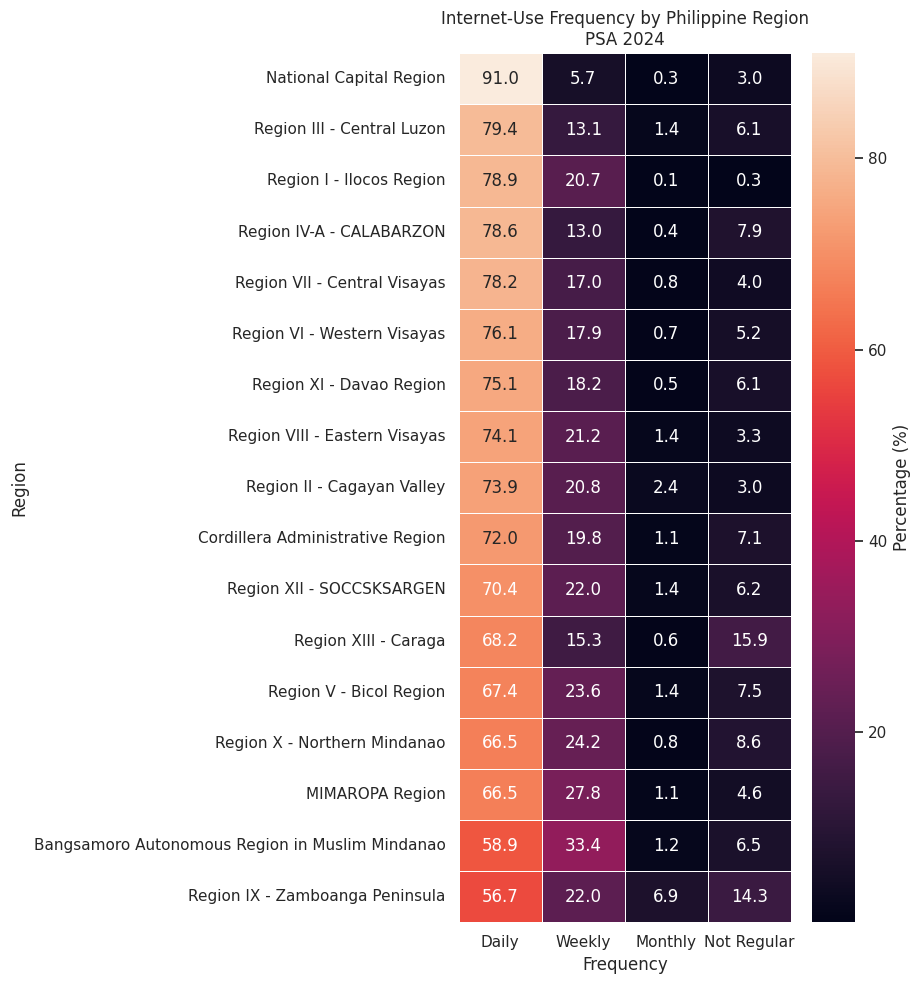

In [303]:
# @title
# ============================================================
# FREQUENCY CANDIDATE 2:
# REGIONAL FREQUENCY HEATMAP
# ============================================================

frequency_heatmap = (
    regional_frequency_profile
    .pivot(
        index="Region",
        columns="Frequency",
        values="Percentage"
    )
    [frequency_order]
)

# Sort regions by Daily use from highest to lowest.
frequency_heatmap = (
    frequency_heatmap
    .sort_values("Daily", ascending=False)
)

plt.figure(figsize=(9, 10))

sns.heatmap(
    frequency_heatmap,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Percentage (%)"
    }
)

plt.title(
    "Internet-Use Frequency by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Frequency")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


#### Candidate 2 Assessment

**Advantages**

- makes category-specific regional differences easier to compare
- exact percentages can be displayed directly
- visually compact because there are only four frequency columns
- useful as an alternative to the Daily-only bar chart

**Downsides**

- does not communicate the part-to-whole composition as directly as a stacked bar
- relies on color intensity for pattern recognition
- may overlap visually with the other heatmaps already being considered

**Current Assessment:** **Strong Supporting Candidate**


### 11.1 Frequency Visualization Comparison

The 100% stacked bar is stronger for showing the **composition of internet-use frequency**.

The heatmap is stronger for comparing exact percentages across regions and categories.

Both remain exploratory alternatives. The group can decide whether either adds enough value beyond the existing Daily-use analysis and reach-versus-frequency bubble chart.


# 12. Gender Composition of Internet Users

## Analytical Questions

1. **How balanced is the recorded gender composition of internet users nationally and across regions?**
2. **Which regions show the largest Female-Male percentage differences?**
3. **Is gender variation large enough to justify a dashboard visualization?**

## Purpose

Gender is included in the original project scope as a demographic variable.

This section checks whether the gender composition of internet users shows meaningful regional differences.

The percentages represent the **composition of recorded internet users by gender**.

They should not be interpreted as the percentage of all males or all females in a region who use the internet.


In [304]:
# @title
# ============================================================
# PREPARE AND VALIDATE GENDER COMPOSITION
# ============================================================

gender_categories = [
    "Female",
    "Male"
]

gender_profile = (
    df_gender[
        df_gender["Gender"].isin(gender_categories)
    ]
    .copy()
)

gender_sum_check = (
    gender_profile
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Gender_Percentage_Sum")
)

print("GENDER-COMPOSITION VALIDATION")
print("-" * 60)
print(
    f"Minimum Female + Male sum: "
    f"{gender_sum_check['Gender_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum Female + Male sum: "
    f"{gender_sum_check['Gender_Percentage_Sum'].max():.1f}%"
)

national_gender = (
    gender_profile[
        gender_profile["Region"] == "PHILIPPINES"
    ]
    [["Gender", "Number", "Percentage"]]
)

display(national_gender)


GENDER-COMPOSITION VALIDATION
------------------------------------------------------------
Minimum Female + Male sum: 100.0%
Maximum Female + Male sum: 100.0%


,Gender,Number,Percentage
5,Female,31816569,51.8
17,Male,29650540,48.2


### Candidate 1: Diverging Gender-Composition Bar Chart

A diverging bar is tested because it places Female and Male shares on opposite sides of the same center line, making small regional differences easier to compare.


/tmp/ipykernel_9916/2950622970.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


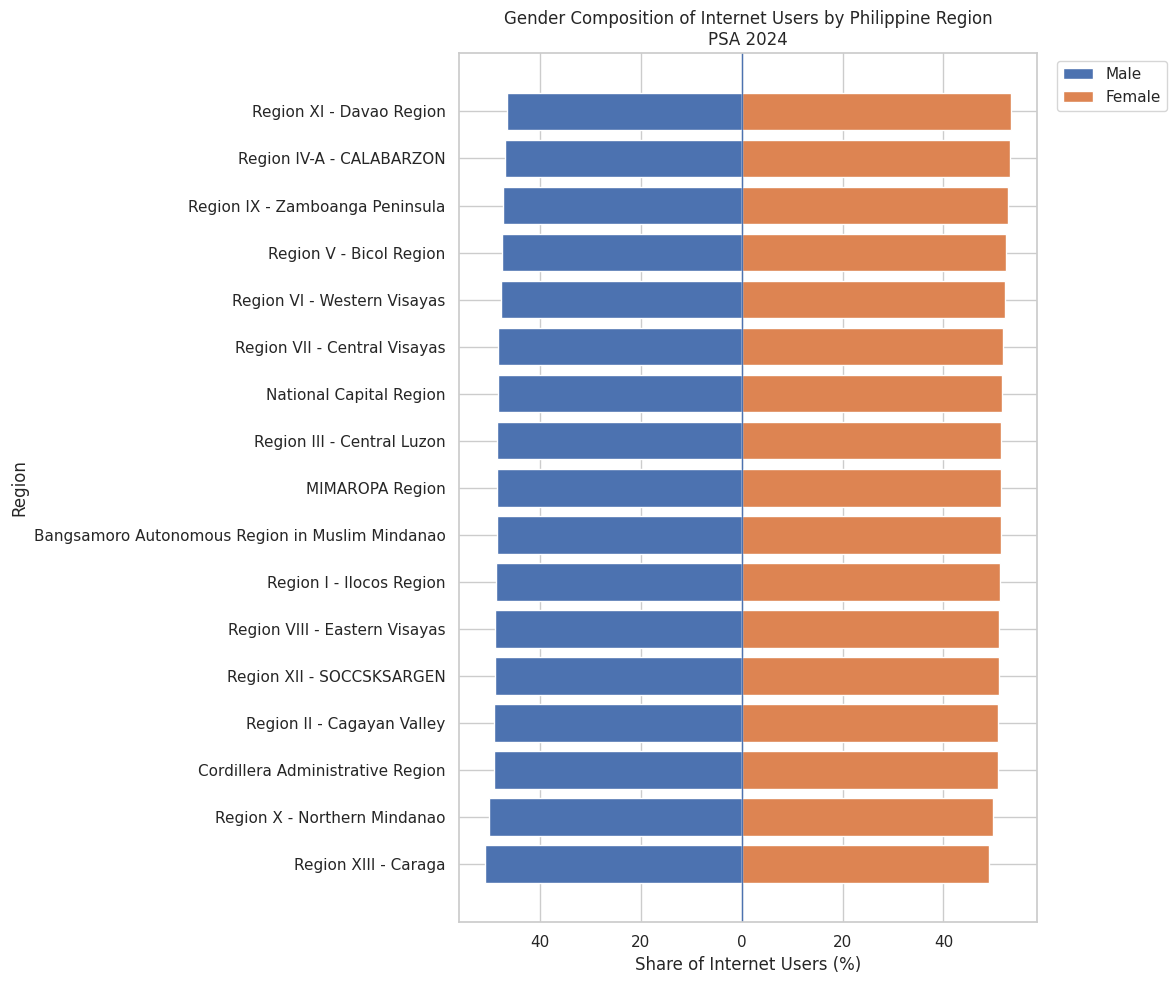

In [305]:
# @title
# ============================================================
# GENDER CANDIDATE 1:
# DIVERGING COMPOSITION BAR CHART
# ============================================================

regional_gender = (
    gender_profile[
        gender_profile["Region"] != "PHILIPPINES"
    ]
    .pivot(
        index="Region",
        columns="Gender",
        values="Percentage"
    )
)

# Sort by Female share for a consistent comparison.
regional_gender = (
    regional_gender
    .sort_values("Female", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    regional_gender.index,
    -regional_gender["Male"],
    label="Male"
)

ax.barh(
    regional_gender.index,
    regional_gender["Female"],
    label="Female"
)

ax.axvline(0, linewidth=1)

# Display absolute percentage values on both sides of the axis.
ticks = ax.get_xticks()
ax.set_xticklabels(
    [f"{abs(tick):.0f}" for tick in ticks]
)

ax.set_title(
    "Gender Composition of Internet Users by Philippine Region\n"
    "PSA 2024"
)

ax.set_xlabel("Share of Internet Users (%)")
ax.set_ylabel("Region")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


#### Candidate 1 Assessment

**Advantages**

- compares Female and Male composition directly for every region
- small differences are easier to notice than with separate bars
- preserves all 17 regional observations
- useful for assessing whether gender composition is relatively balanced

**Downsides**

- negative values are used only for layout and do not represent negative percentages
- a general audience may need a short explanation
- if regional differences are very small, the chart may not justify major dashboard space

**Current Assessment:** **Exploratory Candidate**


### Candidate 2: Female-Male Percentage-Point Gap

A simpler alternative is to calculate the difference:

**Female % - Male %**

Positive values indicate a higher Female share, while negative values indicate a higher Male share.

This is a derived exploratory measure, not an official PSA indicator.


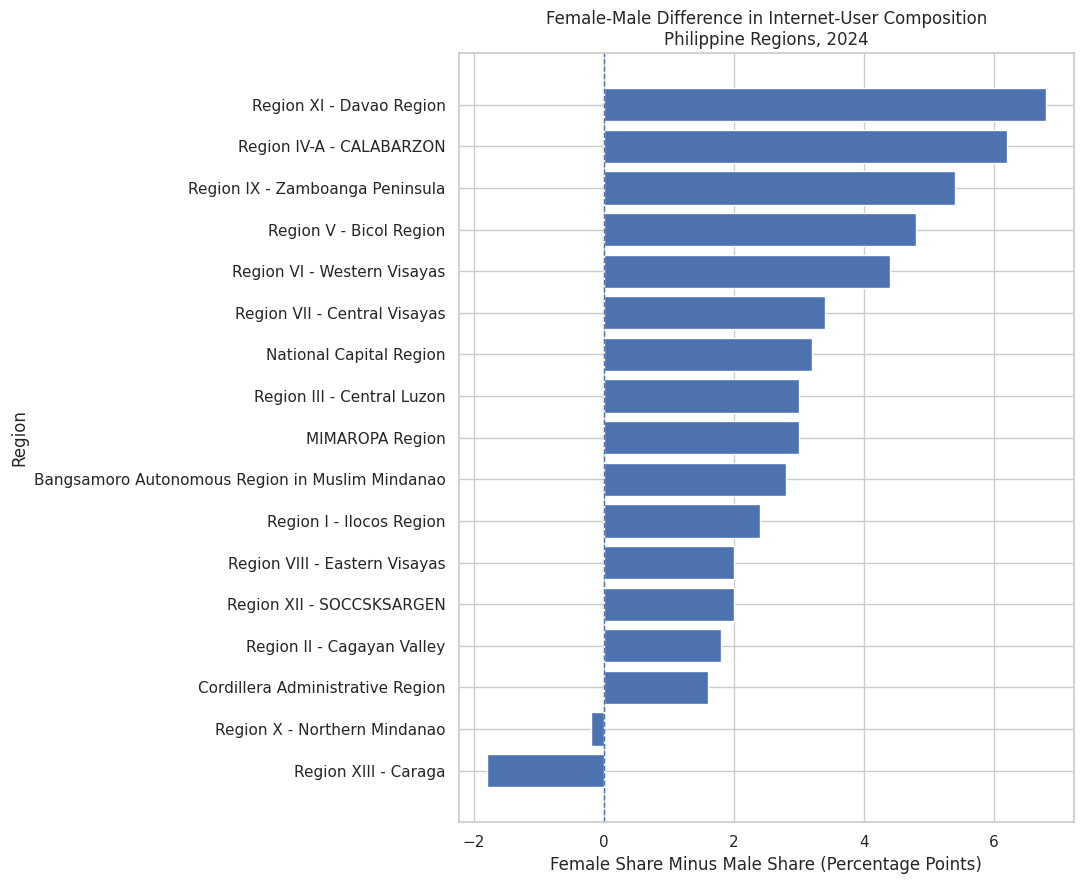

GENDER GAP SUMMARY
------------------------------------------------------------
Largest Female-leading gap: 6.8 percentage points
Largest Male-leading gap: -1.8 percentage points


In [306]:
# @title
# ============================================================
# GENDER CANDIDATE 2:
# FEMALE - MALE PERCENTAGE-POINT GAP
# ============================================================

gender_gap = regional_gender.copy()

gender_gap["Female_Male_Gap"] = (
    gender_gap["Female"]
    - gender_gap["Male"]
)

gender_gap = (
    gender_gap
    .sort_values("Female_Male_Gap")
)

fig, ax = plt.subplots(figsize=(11, 9))

ax.barh(
    gender_gap.index,
    gender_gap["Female_Male_Gap"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Female-Male Difference in Internet-User Composition\n"
    "Philippine Regions, 2024"
)

ax.set_xlabel(
    "Female Share Minus Male Share "
    "(Percentage Points)"
)

ax.set_ylabel("Region")

plt.tight_layout()
plt.show()

print("GENDER GAP SUMMARY")
print("-" * 60)
print(
    f"Largest Female-leading gap: "
    f"{gender_gap['Female_Male_Gap'].max():.1f} percentage points"
)
print(
    f"Largest Male-leading gap: "
    f"{gender_gap['Female_Male_Gap'].min():.1f} percentage points"
)


#### Candidate 2 Assessment

**Advantages**

- directly emphasizes the size and direction of the gender difference
- easier to identify the regions with the largest gaps
- more compact than plotting both percentages separately
- useful for deciding whether gender variation is analytically important

**Downsides**

- hides the original Female and Male percentages unless included in labels or tooltips
- uses a calculated difference rather than a direct source measure
- should not be interpreted as a gender-specific internet penetration gap

**Current Assessment:** **Diagnostic / Exploratory Candidate**


### 12.1 Gender Visualization Comparison

The diverging bar is stronger when the audience needs to see the full Female and Male composition.

The percentage-point gap chart is stronger when the goal is simply to identify where the largest gender differences occur.

If the regional differences are small, the strongest conclusion may be that gender composition is relatively balanced and does not require a major dashboard panel.

That would still be a valid analytical finding.


# Current Visualization Candidates

The table below summarizes the main visualization candidates identified through the exploratory analysis.

These are **working candidates, not final Tableau selections**.

| Insight Area | Current Visualization Candidate | Current Assessment |
|---|---|---|
| Regional differences in overall internet use | **Philippine Choropleth Map** | **Primary Candidate** |
| Overall internet use vs daily-use frequency | **Bubble Scatter Plot with Benchmark Quadrants** | Strong Candidate |
| Working-device access vs overall internet use | **Scatter Plot with Trend Line** | Supporting Candidate / Review |
| Regional network-signal profiles | **Boxed Heatmap / Highlight Table** | Strong Supporting Candidate |
| National internet activities | **Word Cloud or Horizontal Bar Chart** | Exploratory Comparison |
| Regional internet-activity differences | **Regional Activity Heatmap** | Strong Supporting Candidate |
| National age composition | **Age-Profile Bar Chart** | Strong Exploratory Candidate |
| Regional age composition | **Age-Group Heatmap** | Strong Supporting Candidate |
| Full internet-use frequency profile | **100% Stacked Horizontal Bar** | Strong Exploratory Candidate |
| Regional frequency comparison | **Frequency Heatmap** | Strong Supporting Candidate |
| Gender composition | **Diverging Gender Bar** | Exploratory Candidate |
| Regional gender difference | **Female-Male Gap Bar** | Diagnostic / Exploratory Candidate |

## Current Overall Position

The Philippine choropleth remains the clearest **primary candidate** because the project focuses on regional digital-connectivity differences.

The remaining visualizations are being compared based on:

- clarity
- analytical value
- audience relevance
- dashboard space
- redundancy with other charts
- group agreement

At this stage, the exploratory notebook covers the main dimensions available in the PSA datasets:

**Where people use the internet → How often they use it → What they do online → What devices and signals are associated with connectivity → Who the recorded internet users are by age and gender.**

The next step after reviewing these exploratory outputs should be to narrow the candidates for the final Tableau dashboard rather than continue adding new analytical sections.
